edge                start ->            end  bends  colour
upwelling     (0.0, -1.2) ->   (0.0, -0.35)    0    #2E7FC1
uptake        (0.0, 0.35) ->    (0.0, 1.57)    0    #1E7D34
mortality    (-0.42, 2.0) ->   (-0.35, 0.0)    2    #7D4FB0


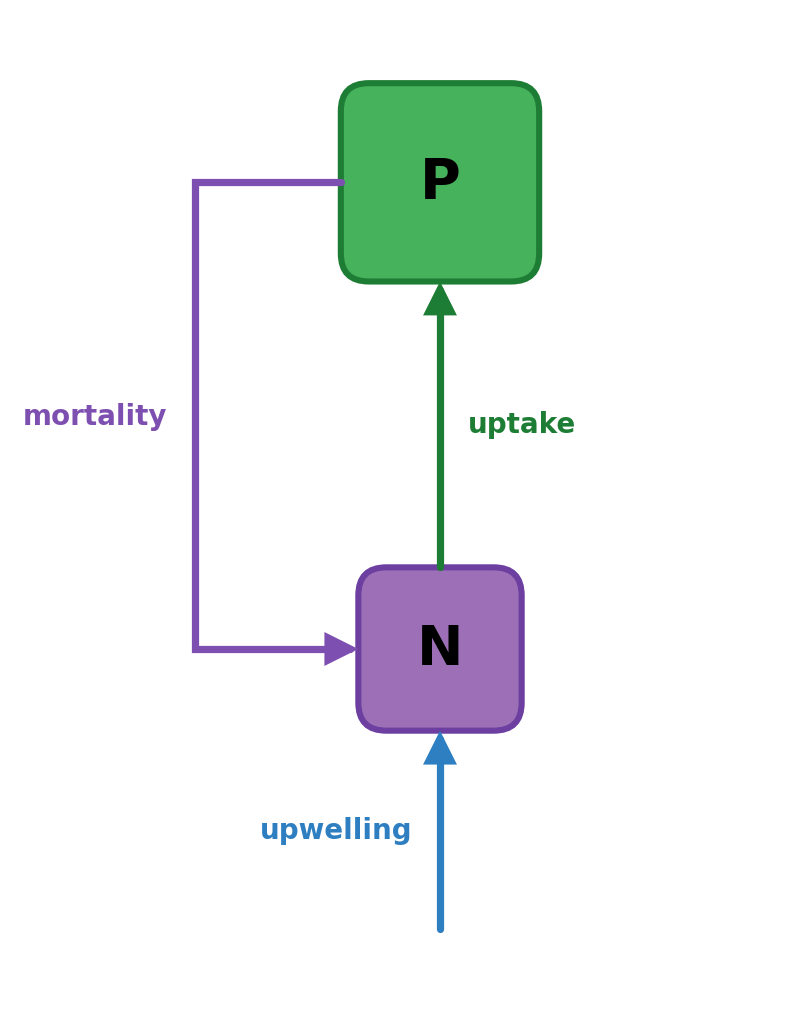

In [2]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path

# ===================== PALETTE =====================
FILL  = {'N': '#9C6FB6', 'P': '#46B25B'}
EDGE  = {'N': '#6C3FA0', 'P': '#1E7D34'}
ARROW = {'N': '#7D4FB0', 'P': '#1E7D34'}   # arrow = colour of pool it flows INTO
BLUE  = '#2E7FC1'                          # external (export would be black)

# ===================== NODE SPEC ===================
nodes = {
    'N': dict(x=0.0, y=0.0, w=0.70, h=0.70),
    'P': dict(x=0.0, y=2.0, w=0.85, h=0.85),
}

# ===================== EDGE SPEC ===================
# ports: (node, side, OFFSET-from-face-centre in plot units); 'below' source = ('below', offset)
# route 'straight' => equal x (or y) at both ends => exactly vertical/horizontal.
# route 'side'     => exit a left/right face, run to `lane` x, then orthogonal in.
edges = [
    dict(name='upwelling', route='straight', kind='boundary', head='closed',
         src=('below', 0.0), dst=('N','bottom',0.0), label='upwelling', lab='left'),
    dict(name='uptake',    route='straight', kind='flux', head='closed',
         src=('N','top',0.0), dst=('P','bottom',0.0), label='uptake', lab='right'),
    dict(name='mortality', route='side', kind='flux', head='closed', lane=-1.05,
         src=('P','left',0.0), dst=('N','left',0.0), label='mortality', lab='left'),
]

# ===================== MECHANICAL RENDERER =========
def port(node, side, off=0.0):
    n = nodes[node]; x,y,w,h = n['x'],n['y'],n['w'],n['h']
    return {'top':    (x+off, y+h/2),
            'bottom': (x+off, y-h/2),
            'left':   (x-w/2, y+off),
            'right':  (x+w/2, y+off)}[side]

def waypoints(e):
    if e['src'][0] == 'below':                       # boundary stub from open space
        b = nodes[e['dst'][0]]; sx = b['x'] + e['src'][1]
        start = (sx, b['y'] - b['h']/2 - 0.85)
    else:
        start = port(*e['src'])
    end = port(*e['dst'])
    if e['route'] == 'straight':
        return [start, end]
    L = e['lane']                                    # H to lane, V to end's height, H into end
    return [start, (L, start[1]), (L, end[1]), end]

def colour(e):
    if e['kind'] == 'boundary': return BLUE
    if e['kind'] == 'export':   return 'black'
    return ARROW[e['dst'][0]]

def draw_arrow(ax, pts, col, head):
    path = Path(pts, [Path.MOVETO] + [Path.LINETO]*(len(pts)-1))
    ax.add_patch(FancyArrowPatch(
        path=path, arrowstyle='-|>', mutation_scale=20, lw=2.6,
        edgecolor=col, facecolor=(col if head=='closed' else 'white'),
        shrinkA=0, shrinkB=0, joinstyle='miter', zorder=3))

fig, ax = plt.subplots(figsize=(4.6, 5.2))

for k, n in nodes.items():
    ax.add_patch(FancyBboxPatch((n['x']-n['w']/2, n['y']-n['h']/2), n['w'], n['h'],
                 boxstyle='round,pad=0,rounding_size=0.12',
                 fc=FILL[k], ec=EDGE[k], lw=2.2, zorder=2))
    ax.text(n['x'], n['y'], k, ha='center', va='center',
            fontsize=20, fontweight='bold', zorder=4)

print(f"{'edge':10s} {'start':>14s} -> {'end':>14s}  bends  colour")
for e in edges:
    pts = waypoints(e); col = colour(e)
    draw_arrow(ax, pts, col, e['head'])
    segs = list(zip(pts[:-1], pts[1:]))
    (ax0,ay0),(ax1,ay1) = max(segs, key=lambda s:(s[0][0]-s[1][0])**2+(s[0][1]-s[1][1])**2)
    mx, my = (ax0+ax1)/2, (ay0+ay1)/2
    dx = 0.12 if e['lab']=='right' else -0.12
    ax.text(mx+dx, my, e['label'], ha=('left' if dx>0 else 'right'),
            va='center', fontsize=10, fontweight='bold', color=col)
    print(f"{e['name']:10s} {str((round(pts[0][0],2),round(pts[0][1],2))):>14s} -> "
          f"{str((round(pts[-1][0],2),round(pts[-1][1],2))):>14s}  {len(pts)-2:^5d}  {col}")

ax.set_xlim(-1.8, 1.4); ax.set_ylim(-1.5, 2.7)
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
plt.show()

edge                      start ->            end  bends  colour
upwelling          (-0.9, -1.2) ->  (-0.9, -0.35)    0    #2E7FC1
uptake             (-0.9, 0.35) ->   (-0.42, 2.0)    1    #1E7D34
mortality           (0.42, 2.0) ->    (0.9, 0.35)    1    #8A5A2B
remineralisation    (0.55, 0.0) ->   (-0.55, 0.0)    0    #7D4FB0
sinking            (0.9, -0.35) ->    (0.9, -1.2)    0    black


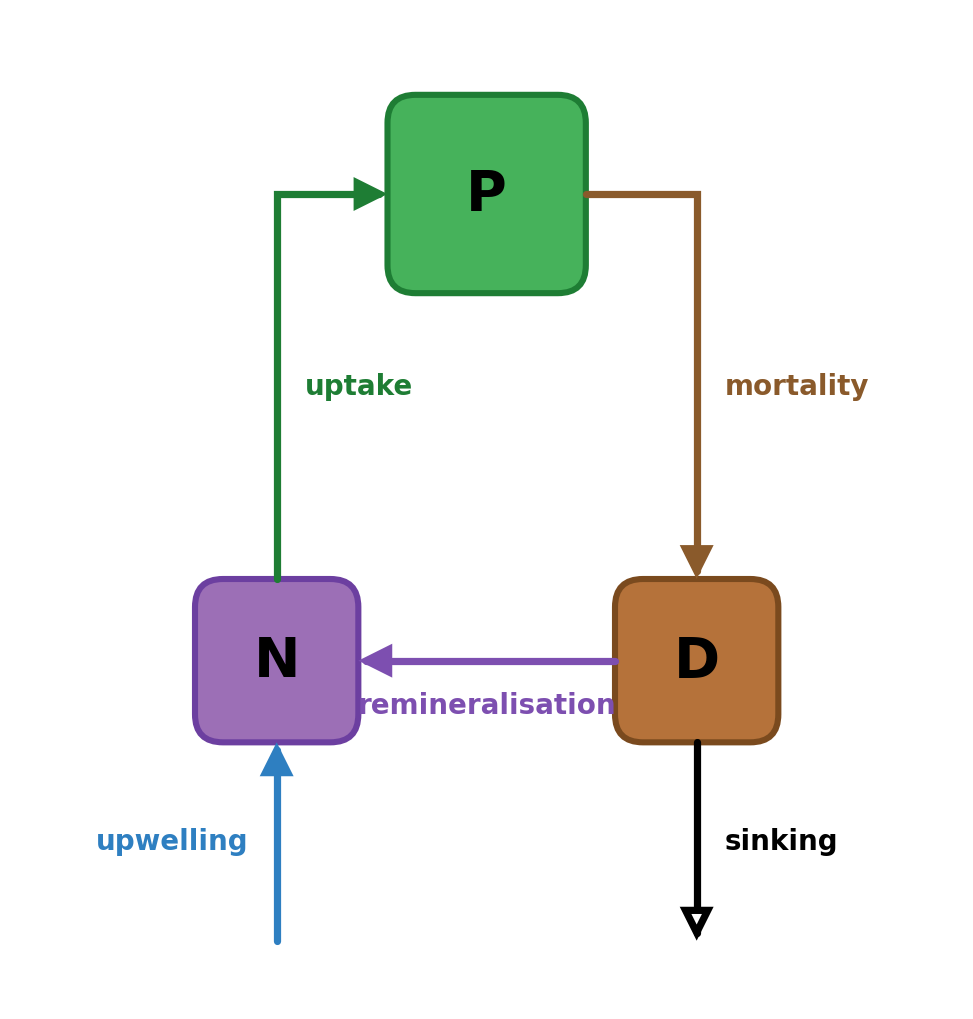

In [3]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path

# ===================== PALETTE =====================
FILL  = {'N':'#9C6FB6', 'P':'#46B25B', 'D':'#B5723A'}
EDGE  = {'N':'#6C3FA0', 'P':'#1E7D34', 'D':'#7A4A1E'}
ARROW = {'N':'#7D4FB0', 'P':'#1E7D34', 'D':'#8A5A2B'}   # arrow = colour of pool it flows INTO
BLUE  = '#2E7FC1'                                        # external in;  export = black

# ===================== NODE SPEC (symmetric: P centred over N–D midpoint) =====================
nodes = {
    'N': dict(x=-0.90, y=0.0, w=0.70, h=0.70),
    'D': dict(x= 0.90, y=0.0, w=0.70, h=0.70),
    'P': dict(x= 0.00, y=2.0, w=0.85, h=0.85),
}

# ===================== EDGE SPEC =====================
# terminals: ('NODE','side',offset) | ('below','NODE',offset) | ('point',x,y)
# routes: straight | L_vh (vert then horiz) | L_hv (horiz then vert) | side (H–lane–V–H)
edges = [
    dict(name='upwelling',       route='straight', kind='boundary', head='closed',
         src=('below','N',0.0),   dst=('N','bottom',0.0), label='upwelling',       lab='left'),
    dict(name='uptake',          route='L_vh',     kind='flux',     head='closed',
         src=('N','top',0.0),     dst=('P','left',0.0),   label='uptake',          lab='right'),
    dict(name='mortality',       route='L_hv',     kind='flux',     head='closed',
         src=('P','right',0.0),   dst=('D','top',0.0),    label='mortality',       lab='right'),
    dict(name='remineralisation',route='straight', kind='flux',     head='closed',
         src=('D','left',0.0),    dst=('N','right',0.0),  label='remineralisation',lab='down'),
    dict(name='sinking',         route='straight', kind='export',   head='open',
         src=('D','bottom',0.0),  dst=('point',0.90,-1.20), label='sinking',       lab='right'),
]

# ===================== MECHANICAL RENDERER =====================
def port(node, side, off=0.0):
    n = nodes[node]; x,y,w,h = n['x'],n['y'],n['w'],n['h']
    return {'top':(x+off,y+h/2),'bottom':(x+off,y-h/2),
            'left':(x-w/2,y+off),'right':(x+w/2,y+off)}[side]

def resolve(t):
    if t[0] in nodes:    return port(*t)
    if t[0] == 'below':  b=nodes[t[1]]; return (b['x']+t[2], b['y']-b['h']/2-0.85)
    if t[0] == 'point':  return (t[1], t[2])

def waypoints(e):
    s, t = resolve(e['src']), resolve(e['dst']); r = e['route']
    if r == 'straight': return [s, t]
    if r == 'L_vh':     return [s, (s[0], t[1]), t]          # vertical, then horizontal in
    if r == 'L_hv':     return [s, (t[0], s[1]), t]          # horizontal, then vertical in
    if r == 'side':     L=e['lane']; return [s, (L,s[1]), (L,t[1]), t]

def colour(e):
    if e['kind'] == 'boundary': return BLUE
    if e['kind'] == 'export':   return 'black'
    return ARROW[e['dst'][0]]

def draw_arrow(ax, pts, col, head):
    path = Path(pts, [Path.MOVETO] + [Path.LINETO]*(len(pts)-1))
    ax.add_patch(FancyArrowPatch(
        path=path, arrowstyle='-|>', mutation_scale=20, lw=2.6,
        edgecolor=col, facecolor=(col if head=='closed' else 'white'),
        shrinkA=0, shrinkB=0, joinstyle='miter', zorder=3))

LAB = {'left':(-0.12,0,'right','center'), 'right':(0.12,0,'left','center'),
       'up':(0,0.13,'center','bottom'),   'down':(0,-0.13,'center','top')}

fig, ax = plt.subplots(figsize=(5.2, 5.2))

for k, n in nodes.items():
    ax.add_patch(FancyBboxPatch((n['x']-n['w']/2, n['y']-n['h']/2), n['w'], n['h'],
                 boxstyle='round,pad=0,rounding_size=0.12',
                 fc=FILL[k], ec=EDGE[k], lw=2.2, zorder=2))
    ax.text(n['x'], n['y'], k, ha='center', va='center', fontsize=20, fontweight='bold', zorder=4)

print(f"{'edge':16s} {'start':>14s} -> {'end':>14s}  bends  colour")
for e in edges:
    pts = waypoints(e); col = colour(e)
    draw_arrow(ax, pts, col, e['head'])
    seg = max(zip(pts[:-1], pts[1:]), key=lambda s:(s[0][0]-s[1][0])**2+(s[0][1]-s[1][1])**2)
    mx, my = (seg[0][0]+seg[1][0])/2, (seg[0][1]+seg[1][1])/2
    dx, dy, ha, va = LAB[e['lab']]
    ax.text(mx+dx, my+dy, e['label'], ha=ha, va=va, fontsize=10, fontweight='bold', color=col)
    print(f"{e['name']:16s} {str((round(pts[0][0],2),round(pts[0][1],2))):>14s} -> "
          f"{str((round(pts[-1][0],2),round(pts[-1][1],2))):>14s}  {len(pts)-2:^5d}  {col}")

ax.set_xlim(-2.0, 2.0); ax.set_ylim(-1.45, 2.75)
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
plt.show()

edge                      start ->            end  bends  colour
upwelling          (-0.9, -1.2) ->  (-0.9, -0.35)    0    #2E7FC1
uptake             (-0.9, 0.35) ->   (-0.42, 2.0)    1    #1E7D34
mortality           (0.0, 1.57) ->    (0.9, 0.35)    2    #8A5A2B
mortality_to_N      (0.0, 1.05) ->   (-1.25, 0.0)    2    #7D4FB0
remineralisation    (0.55, 0.0) ->   (-0.55, 0.0)    0    #7D4FB0
sinking            (0.9, -0.35) ->    (0.9, -1.2)    0    black


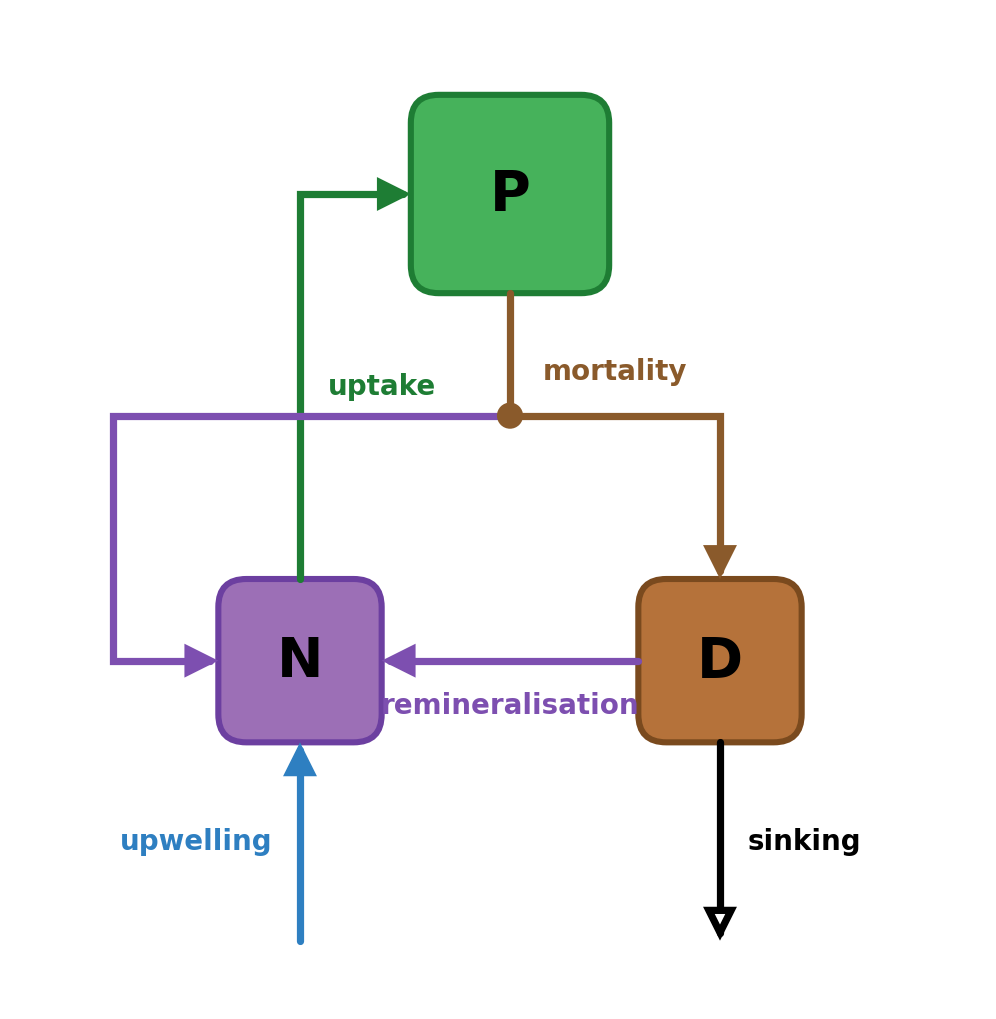

In [4]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path

# ===================== PALETTE =====================
FILL  = {'N':'#9C6FB6', 'P':'#46B25B', 'D':'#B5723A'}
EDGE  = {'N':'#6C3FA0', 'P':'#1E7D34', 'D':'#7A4A1E'}
ARROW = {'N':'#7D4FB0', 'P':'#1E7D34', 'D':'#8A5A2B'}   # arrow = colour of pool it flows INTO
BLUE  = '#2E7FC1'                                        # external in;  export = black

# ===================== NODE SPEC =====================
nodes = {
    'N': dict(x=-0.90, y=0.0, w=0.70, h=0.70),
    'D': dict(x= 0.90, y=0.0, w=0.70, h=0.70),
    'P': dict(x= 0.00, y=2.0, w=0.85, h=0.85),
}
J = (0.0, 1.05)   # mortality fork junction (on the brown trunk)

# ===================== EDGE SPEC =====================
# terminals: ('NODE','side',off) | ('below','NODE',off) | ('point',x,y)
# routes: straight | L_vh | L_hv | side(lane) | poly(via=[pts])
edges = [
    dict(name='upwelling',       route='straight', kind='boundary', head='closed',
         src=('below','N',0.0),   dst=('N','bottom',0.0),  label='upwelling',       lab='left'),
    dict(name='uptake',          route='L_vh',     kind='flux',     head='closed',
         src=('N','top',0.0),     dst=('P','left',0.0),    label='uptake',          lab='right'),
    dict(name='mortality',       route='poly',     kind='flux',     head='closed',   # main -> D (brown)
         src=('P','bottom',0.0),  dst=('D','top',0.0),     via=[J, (0.90, J[1])],
         label='mortality',       lab='up'),
    dict(name='mortality_to_N',  route='poly',     kind='flux',     head='closed',   # split -> N (purple)
         src=('point',)+J,        dst=('N','left',0.0),    via=[(-1.70, J[1]), (-1.70, 0.0)],
         label=None,              lab='left'),
    dict(name='remineralisation',route='straight', kind='flux',     head='closed',
         src=('D','left',0.0),    dst=('N','right',0.0),   label='remineralisation',lab='down'),
    dict(name='sinking',         route='straight', kind='export',   head='open',
         src=('D','bottom',0.0),  dst=('point',0.90,-1.20),label='sinking',         lab='right'),
]

# ===================== MECHANICAL RENDERER =====================
def port(node, side, off=0.0):
    n = nodes[node]; x,y,w,h = n['x'],n['y'],n['w'],n['h']
    return {'top':(x+off,y+h/2),'bottom':(x+off,y-h/2),
            'left':(x-w/2,y+off),'right':(x+w/2,y+off)}[side]

def resolve(t):
    if t[0] in nodes:    return port(*t)
    if t[0] == 'below':  b=nodes[t[1]]; return (b['x']+t[2], b['y']-b['h']/2-0.85)
    if t[0] == 'point':  return (t[1], t[2])

def waypoints(e):
    s, t = resolve(e['src']), resolve(e['dst']); r = e['route']
    if r == 'straight': return [s, t]
    if r == 'L_vh':     return [s, (s[0], t[1]), t]
    if r == 'L_hv':     return [s, (t[0], s[1]), t]
    if r == 'side':     L=e['lane']; return [s, (L,s[1]), (L,t[1]), t]
    if r == 'poly':     return [s] + list(e['via']) + [t]

def colour(e):
    if e['kind'] == 'boundary': return BLUE
    if e['kind'] == 'export':   return 'black'
    return ARROW[e['dst'][0]]

def draw_arrow(ax, pts, col, head):
    path = Path(pts, [Path.MOVETO] + [Path.LINETO]*(len(pts)-1))
    ax.add_patch(FancyArrowPatch(
        path=path, arrowstyle='-|>', mutation_scale=20, lw=2.6,
        edgecolor=col, facecolor=(col if head=='closed' else 'white'),
        shrinkA=0, shrinkB=0, joinstyle='miter', zorder=3))

LAB = {'left':(-0.12,0,'right','center'), 'right':(0.12,0,'left','center'),
       'up':(0,0.13,'center','bottom'),   'down':(0,-0.13,'center','top')}

fig, ax = plt.subplots(figsize=(5.4, 5.2))

for k, n in nodes.items():
    ax.add_patch(FancyBboxPatch((n['x']-n['w']/2, n['y']-n['h']/2), n['w'], n['h'],
                 boxstyle='round,pad=0,rounding_size=0.12',
                 fc=FILL[k], ec=EDGE[k], lw=2.2, zorder=2))
    ax.text(n['x'], n['y'], k, ha='center', va='center', fontsize=20, fontweight='bold', zorder=4)

print(f"{'edge':16s} {'start':>14s} -> {'end':>14s}  bends  colour")
for e in edges:
    pts = waypoints(e); col = colour(e)
    draw_arrow(ax, pts, col, e['head'])
    if e['label']:
        seg = max(zip(pts[:-1], pts[1:]), key=lambda s:(s[0][0]-s[1][0])**2+(s[0][1]-s[1][1])**2)
        mx, my = (seg[0][0]+seg[1][0])/2, (seg[0][1]+seg[1][1])/2
        dx, dy, ha, va = LAB[e['lab']]
        ax.text(mx+dx, my+dy, e['label'], ha=ha, va=va, fontsize=10, fontweight='bold', color=col)
    print(f"{e['name']:16s} {str((round(pts[0][0],2),round(pts[0][1],2))):>14s} -> "
          f"{str((round(pts[-1][0],2),round(pts[-1][1],2))):>14s}  {len(pts)-2:^5d}  {col}")

ax.add_patch(plt.Circle(J, 0.05, color=ARROW['D'], zorder=5))   # fork marker

ax.set_xlim(-2.1, 2.0); ax.set_ylim(-1.45, 2.75)
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
plt.show()

edge                      start ->            end  bends  colour
upwelling          (-0.9, -1.2) ->  (-0.9, -0.35)    0    #2E7FC1
sinking            (0.9, -0.35) ->    (0.9, -1.2)    0    black
uptake             (-0.9, 0.35) ->   (-0.42, 2.0)    1    #1E7D34
P_mort_D            (0.0, 1.57) ->    (0.9, 0.35)    2    #8A5A2B
P_mort_N            (0.0, 1.05) ->  (-1.25, 0.24)    2    #7D4FB0
remineralisation    (0.55, 0.0) ->   (-0.55, 0.0)    0    #7D4FB0
grazing             (0.0, 2.42) ->    (0.0, 3.58)    0    #C0392B
omnivory           (0.15, 4.42) ->  (-0.15, 4.42)    2    #C0392B
Z_slop_D            (0.42, 4.2) ->  (1.25, -0.18)    2    #8A5A2B
Z_lin_D             (0.42, 4.0) ->    (1.25, 0.0)    2    #8A5A2B
Z_quad_D            (0.42, 3.8) ->   (1.25, 0.18)    2    #8A5A2B
Z_slop_N           (-0.42, 4.2) -> (-1.25, -0.24)    2    #7D4FB0
Z_lin_N            (-0.42, 4.0) -> (-1.25, -0.08)    2    #7D4FB0
Z_quad_N           (-0.42, 3.8) ->  (-1.25, 0.08)    2    #7D4FB0


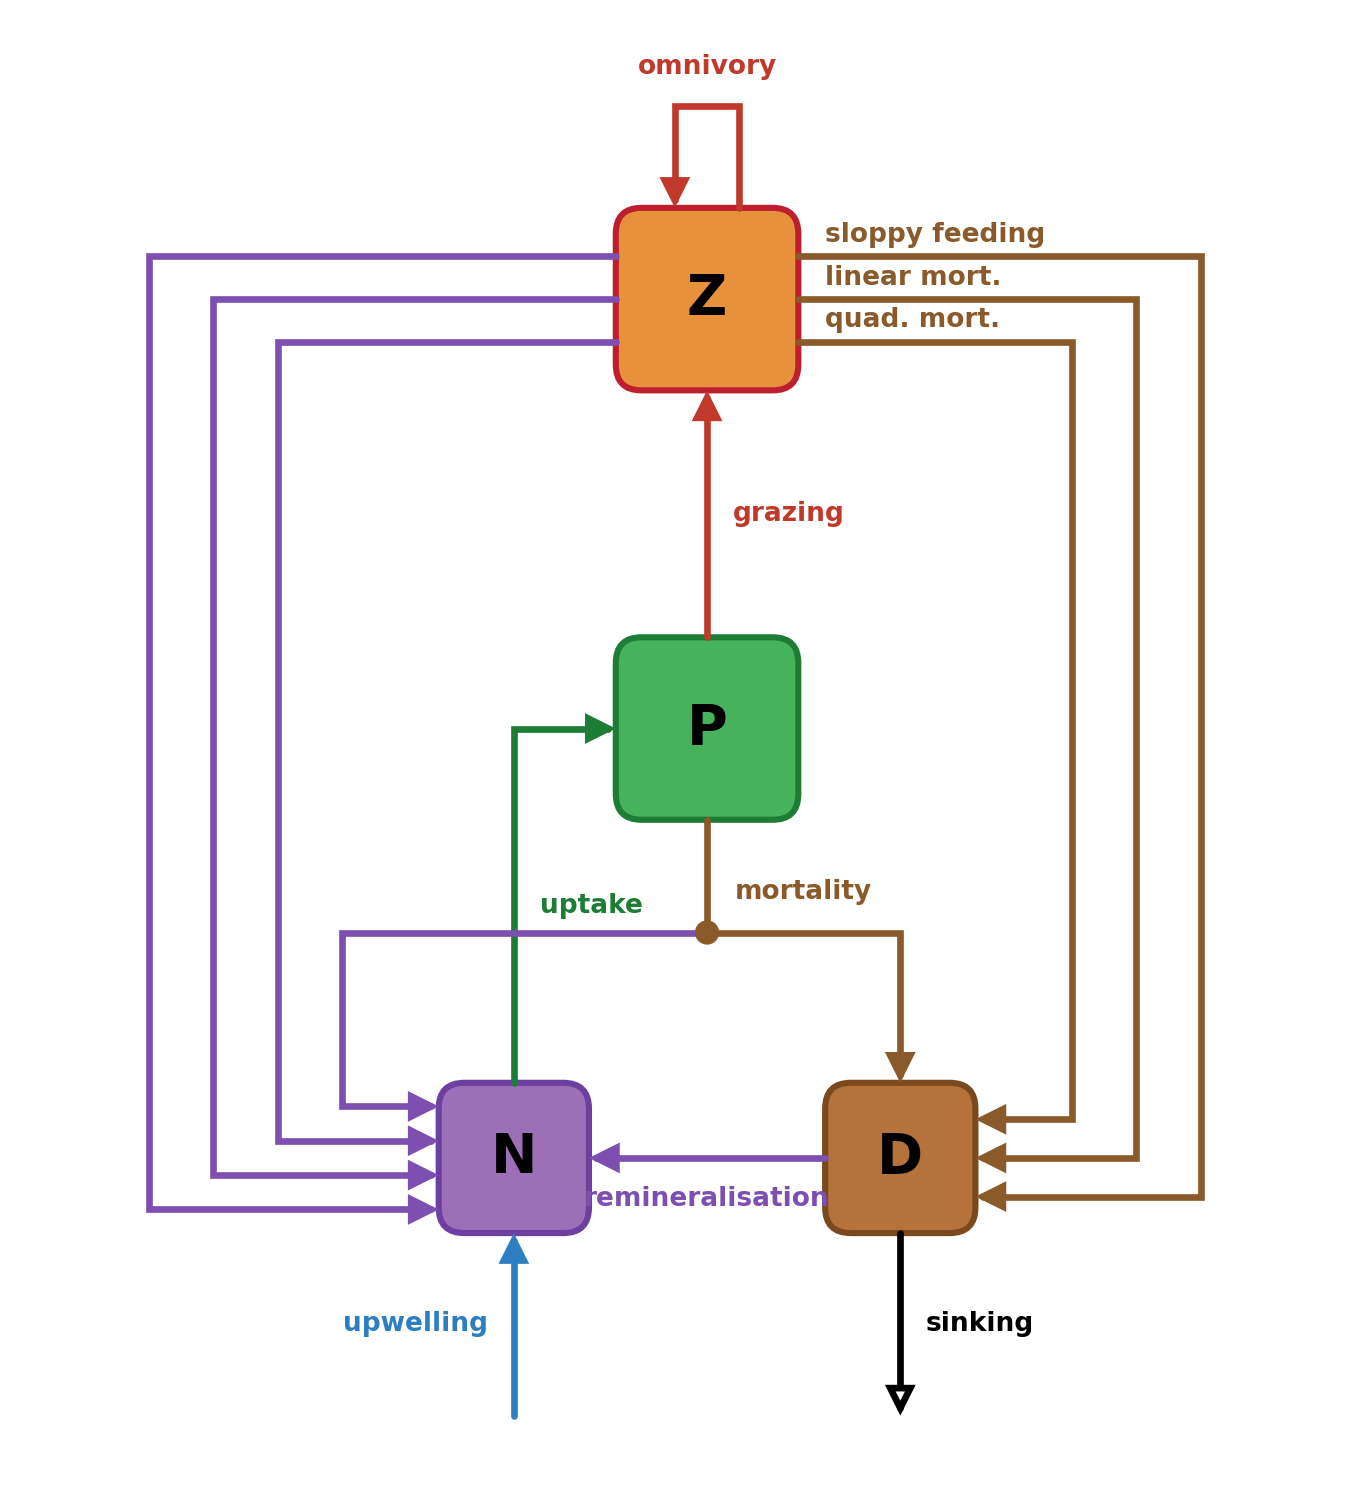

In [5]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path

# ===================== PALETTE =====================
FILL  = {'N':'#9C6FB6','P':'#46B25B','D':'#B5723A','Z':'#E8913C'}
EDGE  = {'N':'#6C3FA0','P':'#1E7D34','D':'#7A4A1E','Z':'#BE1E2D'}
ARROW = {'N':'#7D4FB0','P':'#1E7D34','D':'#8A5A2B','Z':'#C0392B'}  # arrow = colour of pool it flows INTO
BLUE  = '#2E7FC1'                                                   # external in;  export = black

# ===================== NODE SPEC =====================
nodes = {
    'N': dict(x=-0.90, y=0.0, w=0.70, h=0.70),
    'D': dict(x= 0.90, y=0.0, w=0.70, h=0.70),
    'P': dict(x= 0.00, y=2.0, w=0.85, h=0.85),
    'Z': dict(x= 0.00, y=4.0, w=0.85, h=0.85),
}
J = (0.0, 1.05)   # P-mortality fork junction

# ===================== EDGE SPEC =====================
# terminals: ('NODE','side',off) | ('below','NODE',off) | ('point',x,y)
# routes: straight | L_vh | L_hv | side(lane) | poly(via=[pts])
# Z-loss combs use the no-cross rule: TOP source -> OUTER lane -> BOTTOM port.
edges = [
    # ---- boundary ----
    dict(name='upwelling', route='straight', kind='boundary', head='closed',
         src=('below','N',0.0), dst=('N','bottom',0.0), label='upwelling', lab='left'),
    dict(name='sinking', route='straight', kind='export', head='open',
         src=('D','bottom',0.0), dst=('point',0.90,-1.20), label='sinking', lab='right'),
    # ---- N <-> P ----
    dict(name='uptake', route='L_vh', kind='flux', head='closed',
         src=('N','top',0.0), dst=('P','left',0.0), label='uptake', lab='right'),
    dict(name='P_mort_D', route='poly', kind='flux', head='closed',
         src=('P','bottom',0.0), dst=('D','top',0.0), via=[J,(0.90,J[1])], label='mortality', lab='up'),
    dict(name='P_mort_N', route='poly', kind='flux', head='closed',
         src=('point',)+J, dst=('N','left',0.24), via=[(-1.70,J[1]),(-1.70,0.24)], label=None),
    # ---- remineralisation ----
    dict(name='remineralisation', route='straight', kind='flux', head='closed',
         src=('D','left',0.0), dst=('N','right',0.0), label='remineralisation', lab='down'),
    # ---- P -> Z ----
    dict(name='grazing', route='straight', kind='flux', head='closed',
         src=('P','top',0.0), dst=('Z','bottom',0.0), label='grazing', lab='right'),
    # ---- omnivory (Z self-loop) ----
    dict(name='omnivory', route='poly', kind='flux', head='closed',
         src=('Z','top',0.15), dst=('Z','top',-0.15), via=[(0.15,4.90),(-0.15,4.90)],
         label='omnivory', lab_xy=(0.0,5.02), lab_ha='center', lab_va='bottom'),
    # ---- Z losses -> D (brown, right gutter) ----
    dict(name='Z_slop_D', route='side', lane=2.30, kind='flux', head='closed',
         src=('Z','right', 0.20), dst=('D','right',-0.18), label='sloppy feeding',
         lab_xy=(0.55,4.24), lab_ha='left', lab_va='bottom'),
    dict(name='Z_lin_D',  route='side', lane=2.00, kind='flux', head='closed',
         src=('Z','right', 0.00), dst=('D','right', 0.00), label='linear mort.',
         lab_xy=(0.55,4.04), lab_ha='left', lab_va='bottom'),
    dict(name='Z_quad_D', route='side', lane=1.70, kind='flux', head='closed',
         src=('Z','right',-0.20), dst=('D','right', 0.18), label='quad. mort.',
         lab_xy=(0.55,3.84), lab_ha='left', lab_va='bottom'),
    # ---- Z losses -> N (purple, left gutter) ----
    dict(name='Z_slop_N', route='side', lane=-2.60, kind='flux', head='closed',
         src=('Z','left', 0.20), dst=('N','left',-0.24), label=None),
    dict(name='Z_lin_N',  route='side', lane=-2.30, kind='flux', head='closed',
         src=('Z','left', 0.00), dst=('N','left',-0.08), label=None),
    dict(name='Z_quad_N', route='side', lane=-2.00, kind='flux', head='closed',
         src=('Z','left',-0.20), dst=('N','left', 0.08), label=None),
]

# ===================== MECHANICAL RENDERER =====================
def port(node, side, off=0.0):
    n = nodes[node]; x,y,w,h = n['x'],n['y'],n['w'],n['h']
    return {'top':(x+off,y+h/2),'bottom':(x+off,y-h/2),
            'left':(x-w/2,y+off),'right':(x+w/2,y+off)}[side]

def resolve(t):
    if t[0] in nodes:    return port(*t)
    if t[0] == 'below':  b=nodes[t[1]]; return (b['x']+t[2], b['y']-b['h']/2-0.85)
    if t[0] == 'point':  return (t[1], t[2])

def waypoints(e):
    s, t = resolve(e['src']), resolve(e['dst']); r = e['route']
    if r == 'straight': return [s, t]
    if r == 'L_vh':     return [s, (s[0], t[1]), t]
    if r == 'L_hv':     return [s, (t[0], s[1]), t]
    if r == 'side':     L=e['lane']; return [s, (L,s[1]), (L,t[1]), t]
    if r == 'poly':     return [s] + list(e['via']) + [t]

def colour(e):
    if e['kind'] == 'boundary': return BLUE
    if e['kind'] == 'export':   return 'black'
    return ARROW[e['dst'][0]]

def draw_arrow(ax, pts, col, head):
    path = Path(pts, [Path.MOVETO] + [Path.LINETO]*(len(pts)-1))
    ax.add_patch(FancyArrowPatch(
        path=path, arrowstyle='-|>', mutation_scale=18, lw=2.4,
        edgecolor=col, facecolor=(col if head=='closed' else 'white'),
        shrinkA=0, shrinkB=0, joinstyle='miter', zorder=3))

LAB = {'left':(-0.12,0,'right','center'), 'right':(0.12,0,'left','center'),
       'up':(0,0.13,'center','bottom'),   'down':(0,-0.13,'center','top')}

fig, ax = plt.subplots(figsize=(7.0, 7.6))

for k, n in nodes.items():
    ax.add_patch(FancyBboxPatch((n['x']-n['w']/2, n['y']-n['h']/2), n['w'], n['h'],
                 boxstyle='round,pad=0,rounding_size=0.12',
                 fc=FILL[k], ec=EDGE[k], lw=2.2, zorder=2))
    ax.text(n['x'], n['y'], k, ha='center', va='center', fontsize=20, fontweight='bold', zorder=4)

print(f"{'edge':16s} {'start':>14s} -> {'end':>14s}  bends  colour")
for e in edges:
    pts = waypoints(e); col = colour(e)
    draw_arrow(ax, pts, col, e['head'])
    if e['label']:
        if 'lab_xy' in e:
            lx, ly, ha, va = e['lab_xy'][0], e['lab_xy'][1], e.get('lab_ha','center'), e.get('lab_va','center')
        else:
            seg = max(zip(pts[:-1], pts[1:]), key=lambda s:(s[0][0]-s[1][0])**2+(s[0][1]-s[1][1])**2)
            mx, my = (seg[0][0]+seg[1][0])/2, (seg[0][1]+seg[1][1])/2
            dx, dy, ha, va = LAB[e['lab']]; lx, ly = mx+dx, my+dy
        ax.text(lx, ly, e['label'], ha=ha, va=va, fontsize=9.5, fontweight='bold', color=col)
    print(f"{e['name']:16s} {str((round(pts[0][0],2),round(pts[0][1],2))):>14s} -> "
          f"{str((round(pts[-1][0],2),round(pts[-1][1],2))):>14s}  {len(pts)-2:^5d}  {col}")

ax.add_patch(plt.Circle(J, 0.05, color=ARROW['D'], zorder=5))   # P-mortality fork marker

ax.set_xlim(-3.2, 2.9); ax.set_ylim(-1.5, 5.3)
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
plt.show()

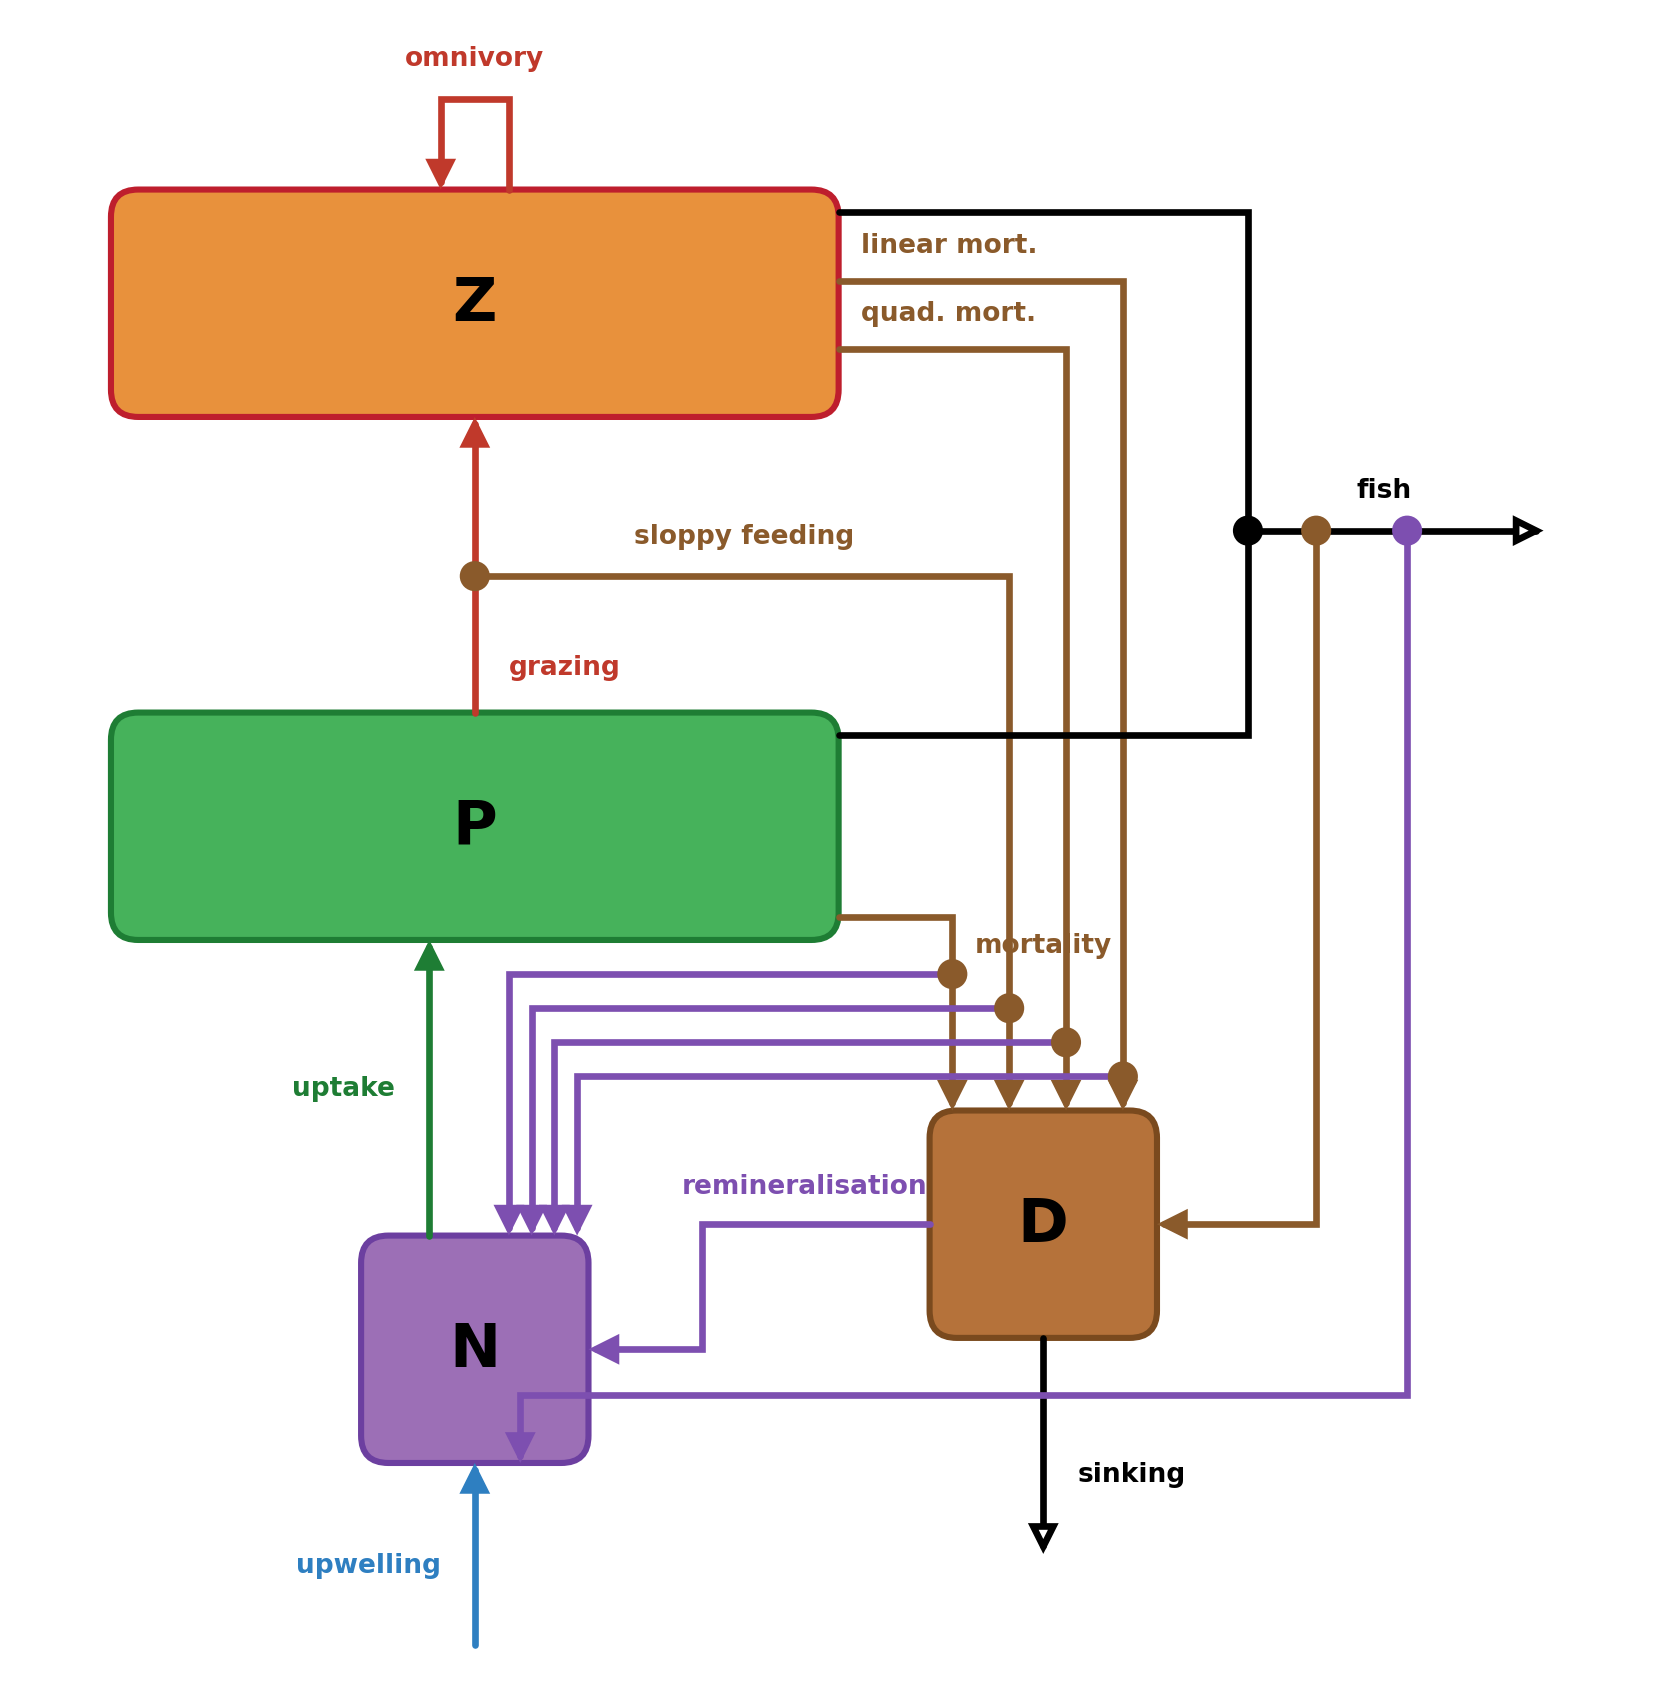

In [6]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path

# ===================== PALETTE =====================
PUR, GRN, BRN, ORG = '#7D4FB0', '#1E7D34', '#8A5A2B', '#C0392B'   # into N / P / D / Z
BLUE, BLACK = '#2E7FC1', 'black'                                   # external in / export
FILL = {'N':'#9C6FB6','P':'#46B25B','Z':'#E8913C','D':'#B5723A'}
EDGE = {'N':'#6C3FA0','P':'#1E7D34','Z':'#BE1E2D','D':'#7A4A1E'}

# ===================== NODE SPEC =====================
# N(0,0) central bottom | P,Z wide & centred above | D lower-right, a bit higher than N
nodes = {
    'N': dict(x=0.0, y=0.0,  w=1.0, h=1.0),   # top .5  bot -.5  L -.5  R .5
    'P': dict(x=0.0, y=2.3,  w=3.2, h=1.0),   # top 2.8 bot 1.8  L -1.6 R 1.6
    'Z': dict(x=0.0, y=4.6,  w=3.2, h=1.0),   # top 5.1 bot 4.1  L -1.6 R 1.6
    'D': dict(x=2.5, y=0.55, w=1.0, h=1.0),   # top 1.05 bot .05 L 2.0  R 3.0
}

# ===================== EDGES (explicit orthogonal polylines) =====================
# head: closed (filled) | open (export) | none (merge feeders)
edges = [
    # ---- boundary & spine ----
    dict(pts=[(0,-1.3),(0,-0.5)],                 col=BLUE,  head='closed', label='upwelling',       lab=(-0.15,-0.95,'right','center')),
    dict(pts=[(-0.2,0.5),(-0.2,1.8)],             col=GRN,   head='closed', label='uptake',          lab=(-0.35,1.15,'right','center')),
    dict(pts=[(0,2.8),(0,4.1)],                   col=ORG,   head='closed', label='grazing',         lab=(0.15,3.0,'left','center')),
    dict(pts=[(0.15,5.1),(0.15,5.5),(-0.15,5.5),(-0.15,5.1)], col=ORG, head='closed', label='omnivory', lab=(0,5.62,'center','bottom')),
    # ---- phyto mortality (short line, same split design) ----
    dict(pts=[(1.6,1.9),(2.1,1.9),(2.1,1.05)],    col=BRN,   head='closed', label='mortality',       lab=(2.2,1.78,'left','center')),
    dict(pts=[(2.1,1.65),(0.15,1.65),(0.15,0.5)], col=PUR,   head='closed'),
    # ---- sloppy feeding (peels off the grazing arrow) ----
    dict(pts=[(0,3.4),(2.35,3.4),(2.35,1.05)],    col=BRN,   head='closed', label='sloppy feeding',  lab=(0.7,3.52,'left','bottom')),
    dict(pts=[(2.35,1.5),(0.25,1.5),(0.25,0.5)],  col=PUR,   head='closed'),
    # ---- quadratic mortality ----
    dict(pts=[(1.6,4.4),(2.6,4.4),(2.6,1.05)],    col=BRN,   head='closed', label='quad. mort.',     lab=(1.7,4.5,'left','bottom')),
    dict(pts=[(2.6,1.35),(0.35,1.35),(0.35,0.5)], col=PUR,   head='closed'),
    # ---- linear mortality ----
    dict(pts=[(1.6,4.7),(2.85,4.7),(2.85,1.05)],  col=BRN,   head='closed', label='linear mort.',    lab=(1.7,4.8,'left','bottom')),
    dict(pts=[(2.85,1.2),(0.45,1.2),(0.45,0.5)],  col=PUR,   head='closed'),
    # ---- remineralisation & sinking ----
    dict(pts=[(2.0,0.55),(1.0,0.55),(1.0,0.0),(0.5,0.0)], col=PUR, head='closed', label='remineralisation', lab=(1.45,0.66,'center','bottom')),
    dict(pts=[(2.5,0.05),(2.5,-0.9)],             col=BLACK, head='open',   label='sinking',         lab=(2.65,-0.55,'left','center')),
    # ---- fish: P+Z merge -> export spine -> N/D peel ----
    dict(pts=[(1.6,5.0),(3.4,5.0),(3.4,3.6)],     col=BLACK, head='none'),                                  # Z feed
    dict(pts=[(1.6,2.7),(3.4,2.7),(3.4,3.6)],     col=BLACK, head='none'),                                  # P feed
    dict(pts=[(3.4,3.6),(4.7,3.6)],               col=BLACK, head='open',   label='fish',            lab=(4.0,3.72,'center','bottom')),  # export
    dict(pts=[(3.7,3.6),(3.7,0.55),(3.0,0.55)],   col=BRN,   head='closed'),                                # -> D
    dict(pts=[(4.1,3.6),(4.1,-0.2),(0.2,-0.2),(0.2,-0.5)], col=PUR, head='closed'),                         # -> N
]

# split-dots (same dot design at every split)
DOTS = [(2.1,1.65,BRN),(0,3.4,BRN),(2.35,1.5,BRN),(2.6,1.35,BRN),(2.85,1.2,BRN),
        (3.4,3.6,BLACK),(3.7,3.6,BRN),(4.1,3.6,PUR)]

# ===================== RENDERER =====================
def draw_arrow(ax, pts, col, head):
    style = {'closed':'-|>','open':'-|>','none':'-'}[head]
    fc = col if head=='closed' else 'white'
    ax.add_patch(FancyArrowPatch(
        path=Path(pts, [Path.MOVETO]+[Path.LINETO]*(len(pts)-1)),
        arrowstyle=style, mutation_scale=18, lw=2.4,
        edgecolor=col, facecolor=fc, shrinkA=0, shrinkB=0, joinstyle='miter', zorder=3))

fig, ax = plt.subplots(figsize=(8.6, 8.6))

for k, n in nodes.items():
    ax.add_patch(FancyBboxPatch((n['x']-n['w']/2, n['y']-n['h']/2), n['w'], n['h'],
                 boxstyle='round,pad=0,rounding_size=0.12', fc=FILL[k], ec=EDGE[k], lw=2.2, zorder=2))
    ax.text(n['x'], n['y'], k, ha='center', va='center', fontsize=22, fontweight='bold', zorder=4)

for e in edges:
    draw_arrow(ax, e['pts'], e['col'], e['head'])
    if e.get('label'):
        lx, ly, ha, va = e['lab']
        ax.text(lx, ly, e['label'], ha=ha, va=va, fontsize=9.5, fontweight='bold', color=e['col'])

for x, y, c in DOTS:
    ax.add_patch(plt.Circle((x, y), 0.06, color=c, zorder=5))

ax.set_xlim(-2.0, 5.1); ax.set_ylim(-1.45, 5.85)
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
plt.show()

labelled fluxes: 11 | total arrows: 23 | split dots: 9


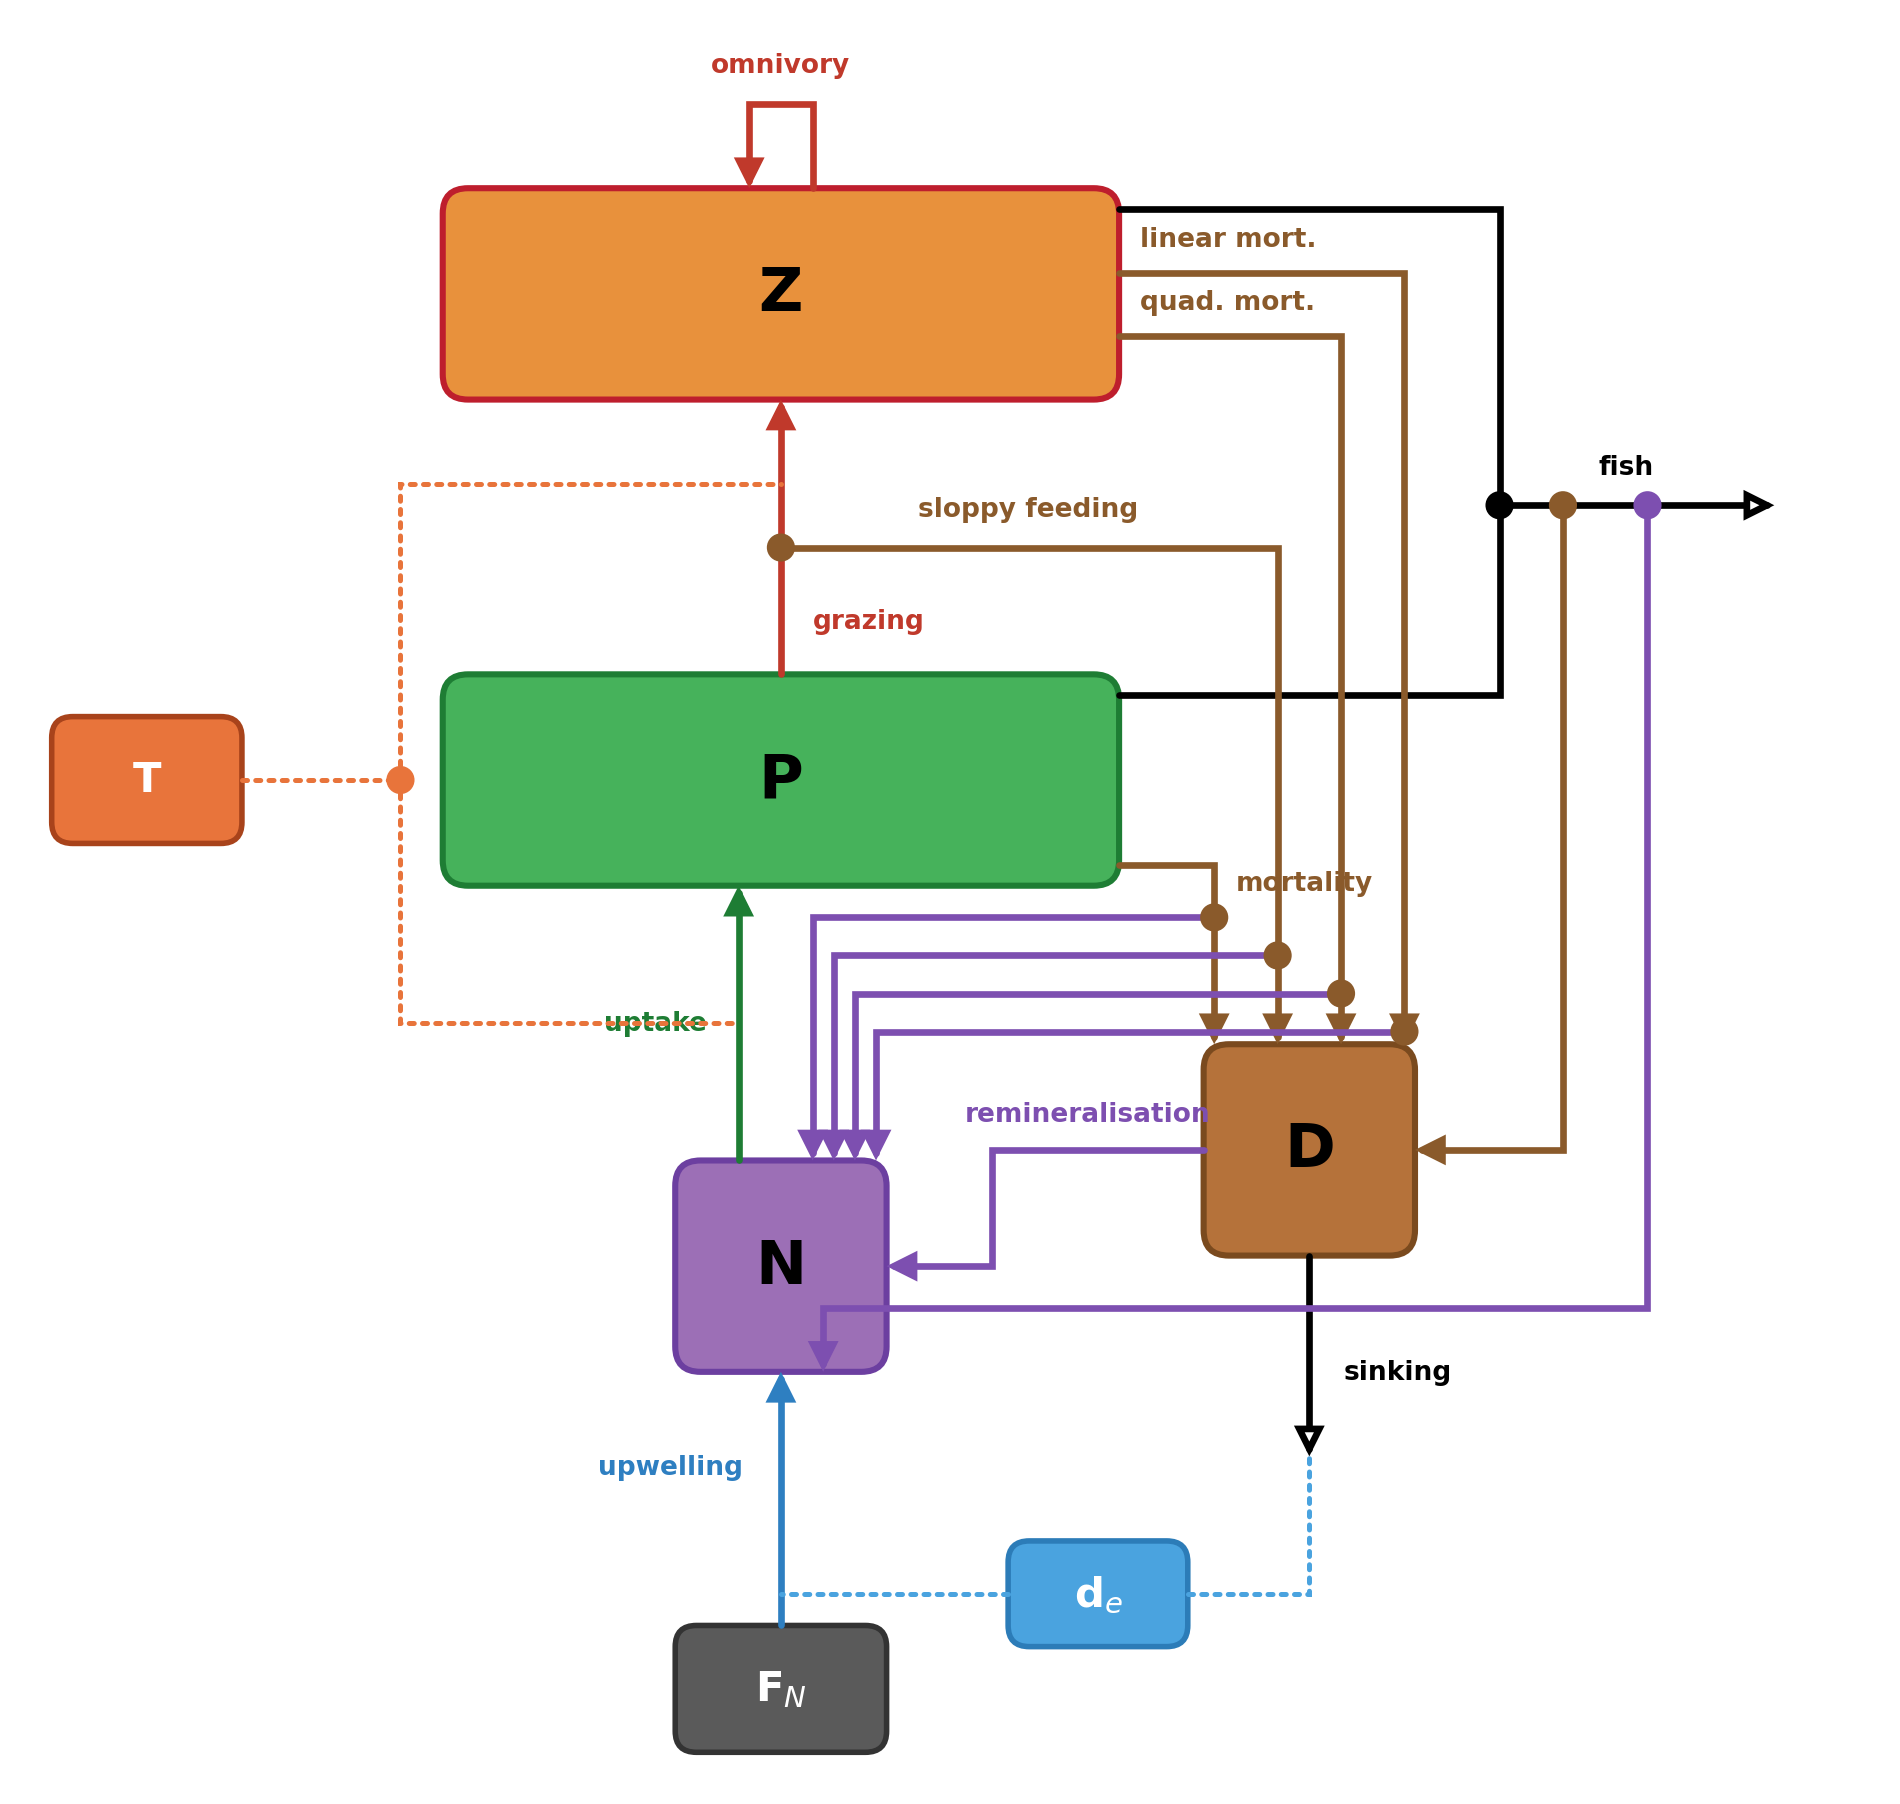

In [11]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path

# ===================== PALETTE =====================
PUR, GRN, BRN, ORG = '#7D4FB0', '#1E7D34', '#8A5A2B', '#C0392B'   # into N / P / D / Z
BLUE, BLACK = '#2E7FC1', 'black'
TCOL, FNCOL, DECOL = '#E8743B', '#5A5A5A', '#4AA3DF'              # forcing: T / F_N / d_e
FILL = {'N':'#9C6FB6','P':'#46B25B','Z':'#E8913C','D':'#B5723A'}
EDGE = {'N':'#6C3FA0','P':'#1E7D34','Z':'#BE1E2D','D':'#7A4A1E'}

# ===================== NODES =====================
nodes = {
    'N': dict(x=0.0, y=0.0,  w=1.0, h=1.0),
    'P': dict(x=0.0, y=2.3,  w=3.2, h=1.0),
    'Z': dict(x=0.0, y=4.6,  w=3.2, h=1.0),
    'D': dict(x=2.5, y=0.55, w=1.0, h=1.0),
}
forcing = {  # forcing inputs (separate styling)
    'T':  dict(x=-3.0, y=2.30, w=0.9,  h=0.60, fc=TCOL,  ec='#A8431B', tc='white', lab='T'),
    'FN': dict(x= 0.0, y=-2.00,w=1.0,  h=0.60, fc=FNCOL, ec='#333333', tc='white', lab=r'F$_N$'),
    'de': dict(x= 1.5, y=-1.55,w=0.85, h=0.50, fc=DECOL, ec='#2C7CB8', tc='white', lab=r'd$_e$'),
}

# ===================== FLUX EDGES =====================
edges = [
    # spine & boundary
    dict(pts=[(0,-1.7),(0,-0.5)],                  col=BLUE, head='closed', label='upwelling',       lab=(-0.18,-0.95,'right','center')),
    dict(pts=[(-0.2,0.5),(-0.2,1.8)],              col=GRN,  head='closed', label='uptake',          lab=(-0.35,1.15,'right','center')),
    dict(pts=[(0,2.8),(0,4.1)],                    col=ORG,  head='closed', label='grazing',         lab=(0.15,3.05,'left','center')),
    dict(pts=[(0.15,5.1),(0.15,5.5),(-0.15,5.5),(-0.15,5.1)], col=ORG, head='closed', label='omnivory', lab=(0,5.62,'center','bottom')),
    # remineralisation & sinking
    dict(pts=[(2.0,0.55),(1.0,0.55),(1.0,0.0),(0.5,0.0)], col=PUR, head='closed', label='remineralisation', lab=(1.45,0.66,'center','bottom')),
    dict(pts=[(2.5,0.05),(2.5,-0.9)],              col=BLACK, head='open',  label='sinking',         lab=(2.66,-0.5,'left','center')),
    # fish: P+Z merge -> export spine -> N/D peel
    dict(pts=[(1.6,5.0),(3.4,5.0),(3.4,3.6)],      col=BLACK, head='none'),
    dict(pts=[(1.6,2.7),(3.4,2.7),(3.4,3.6)],      col=BLACK, head='none'),
    dict(pts=[(3.4,3.6),(4.7,3.6)],                col=BLACK, head='open',  label='fish', lab=(4.0,3.72,'center','bottom')),
    dict(pts=[(3.7,3.6),(3.7,0.55),(3.0,0.55)],    col=BRN,   head='closed'),
    dict(pts=[(4.1,3.6),(4.1,-0.2),(0.2,-0.2),(0.2,-0.5)], col=PUR, head='closed'),
    # forcing (dotted modulation links)
    dict(pts=[(-2.55,2.3),(-1.8,2.3),(-1.8,3.7),(0,3.7)], col=TCOL, head='none', ls=':', lw=1.8),   # T -> grazing
    dict(pts=[(-1.8,2.3),(-1.8,1.15),(-0.2,1.15)],        col=TCOL, head='none', ls=':', lw=1.8),   # T -> growth
    dict(pts=[(1.075,-1.55),(0,-1.55)],                   col=DECOL,head='none', ls=':', lw=1.8),   # d_e -> supply
    dict(pts=[(1.925,-1.55),(2.5,-1.55),(2.5,-0.9)],      col=DECOL,head='none', ls=':', lw=1.8),   # d_e -> sinking
]

# ===================== RIGHT CHANNEL (uniform spacing) =====================
LX0, STEP   = 2.05, 0.30   # lane x:        inner -> outer
DOTY0, DOTYS= 1.65, 0.18   # split-dot y:   high  -> low
NX0, NXS    = 0.15, 0.10   # N.top entry x: near  -> far
ch_defs = [((1.6,1.9),'mortality',(2.15,1.75)), ((0.0,3.4),'sloppy feeding',(0.65,3.52)),
           ((1.6,4.4),'quad. mort.',(1.7,4.5)), ((1.6,4.7),'linear mort.',(1.7,4.8))]
DOTS = []
for i,(src,label,lab) in enumerate(ch_defs):
    lx, dy, nx = LX0+i*STEP, DOTY0-i*DOTYS, NX0+i*NXS
    edges.append(dict(pts=[src,(lx,src[1]),(lx,1.05)], col=BRN, head='closed', label=label, lab=(lab[0],lab[1],'left','bottom')))
    edges.append(dict(pts=[(lx,dy),(nx,dy),(nx,0.5)],  col=PUR, head='closed'))
    DOTS.append((lx,dy,BRN))
DOTS += [(0.0,3.4,BRN), (3.4,3.6,BLACK),(3.7,3.6,BRN),(4.1,3.6,PUR), (-1.8,2.3,TCOL)]

# ===================== RENDERER =====================
def draw_arrow(ax, pts, col, head, ls='-', lw=2.4):
    style = {'closed':'-|>','open':'-|>','none':'-'}[head]
    ax.add_patch(FancyArrowPatch(path=Path(pts, [Path.MOVETO]+[Path.LINETO]*(len(pts)-1)),
        arrowstyle=style, mutation_scale=18, lw=lw, edgecolor=col,
        facecolor=(col if head=='closed' else 'white'), shrinkA=0, shrinkB=0,
        joinstyle='miter', linestyle=ls, zorder=3))

fig, ax = plt.subplots(figsize=(9.6, 9.2))

for k, n in nodes.items():
    ax.add_patch(FancyBboxPatch((n['x']-n['w']/2, n['y']-n['h']/2), n['w'], n['h'],
                 boxstyle='round,pad=0,rounding_size=0.12', fc=FILL[k], ec=EDGE[k], lw=2.2, zorder=2))
    ax.text(n['x'], n['y'], k, ha='center', va='center', fontsize=22, fontweight='bold', zorder=4)

for k, f in forcing.items():
    ax.add_patch(FancyBboxPatch((f['x']-f['w']/2, f['y']-f['h']/2), f['w'], f['h'],
                 boxstyle='round,pad=0,rounding_size=0.10', fc=f['fc'], ec=f['ec'], lw=2.0, zorder=2))
    ax.text(f['x'], f['y'], f['lab'], ha='center', va='center', fontsize=15, fontweight='bold', color=f['tc'], zorder=4)

for e in edges:
    draw_arrow(ax, e['pts'], e['col'], e['head'], e.get('ls','-'), e.get('lw',2.4))
    if e.get('label'):
        lx, ly, ha, va = e['lab']
        ax.text(lx, ly, e['label'], ha=ha, va=va, fontsize=9.5, fontweight='bold', color=e['col'])


print('labelled fluxes:', sum(1 for e in edges if e.get('label')), '| total arrows:', len(edges), '| split dots:', len(DOTS))
ax.set_xlim(-3.6, 5.2); ax.set_ylim(-2.45, 5.9)
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()

for x, y, c in DOTS:
    ax.add_patch(plt.Circle((x, y), 0.06, color=c, zorder=5))
    
plt.show()

fig.savefig('npzd_schematic.svg', bbox_inches='tight', pad_inches=0.05, transparent=True)


arrows: 23 | split dots: 9 | N & D entries both at step 0.3


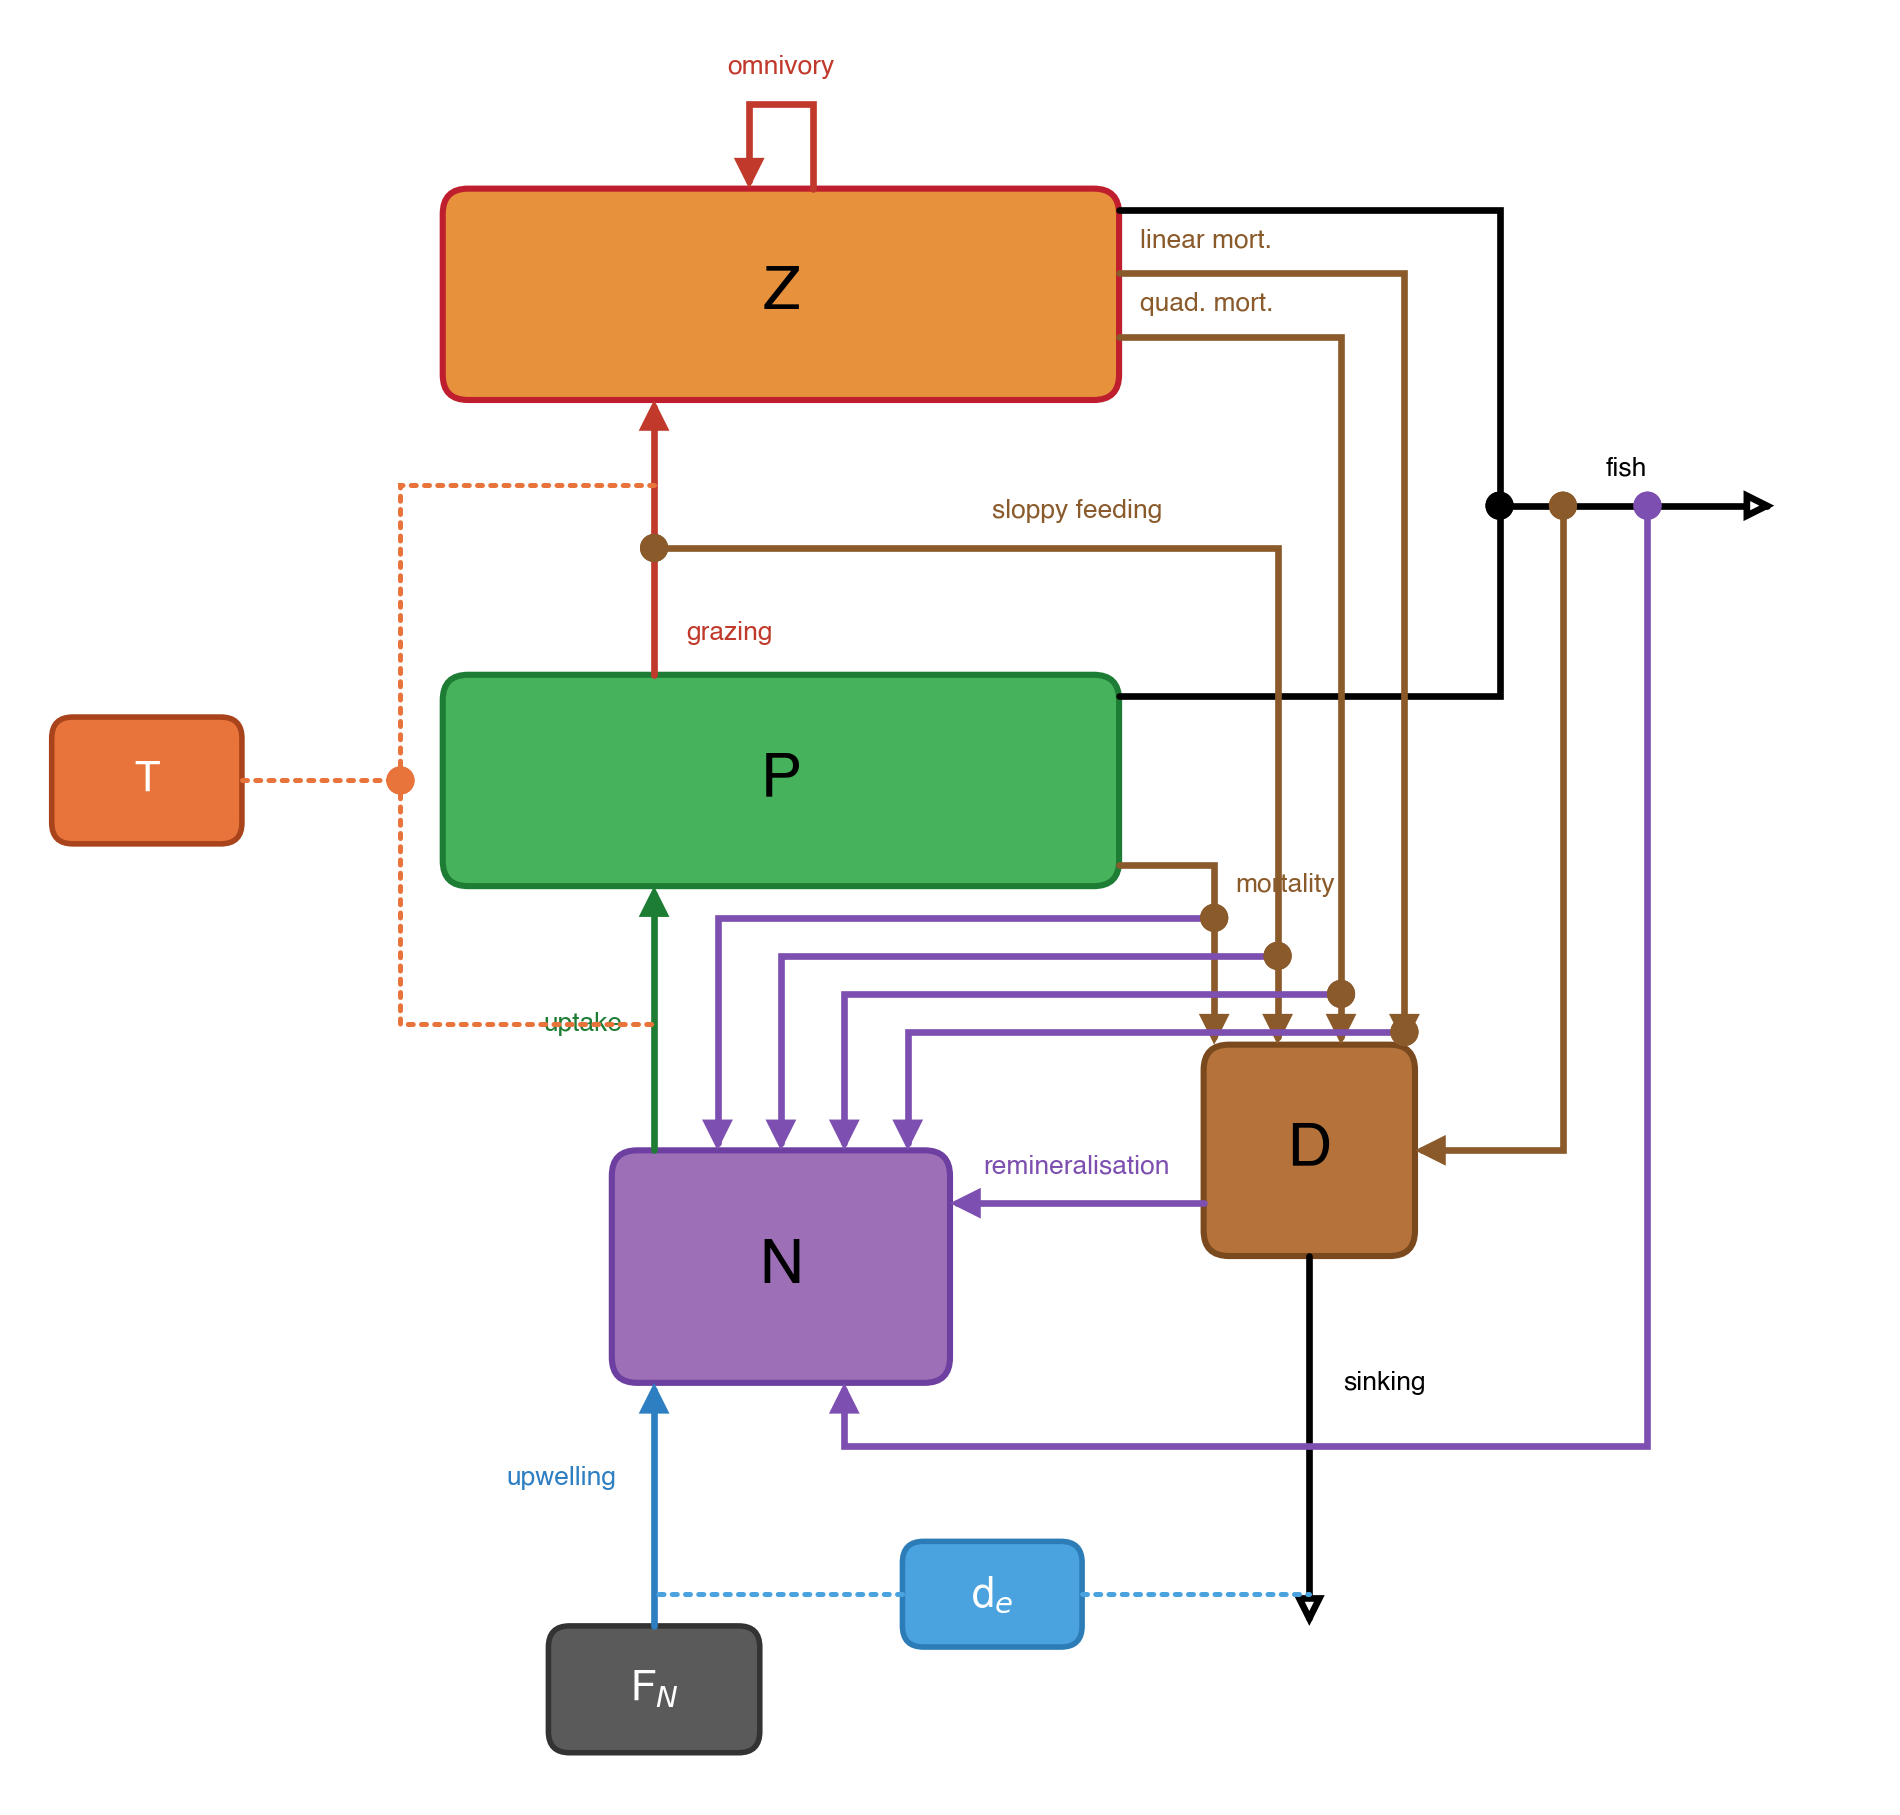

In [12]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path

plt.rcParams['svg.fonttype'] = 'none'      # labels stay as editable <text>, not outlined paths
plt.rcParams['font.family']  = 'Helvetica' # optional: a font AI has, so text renders 1:1


# ===================== PALETTE =====================
PUR, GRN, BRN, ORG = '#7D4FB0', '#1E7D34', '#8A5A2B', '#C0392B'
BLUE, BLACK = '#2E7FC1', 'black'
TCOL, FNCOL, DECOL = '#E8743B', '#5A5A5A', '#4AA3DF'
FILL = {'N':'#9C6FB6','P':'#46B25B','Z':'#E8913C','D':'#B5723A'}
EDGE = {'N':'#6C3FA0','P':'#1E7D34','Z':'#BE1E2D','D':'#7A4A1E'}
SX = -0.6   # production-spine x

# ===================== NODES =====================
nodes = {
    'N': dict(x=0.0, y=0.0,  w=1.6, h=1.1),   # top .55  bot -.55  L -.8  R .8
    'P': dict(x=0.0, y=2.3,  w=3.2, h=1.0),
    'Z': dict(x=0.0, y=4.6,  w=3.2, h=1.0),
    'D': dict(x=2.5, y=0.55, w=1.0, h=1.0),
}
forcing = {
    'T':  dict(x=-3.0, y=2.30, w=0.9,  h=0.60, fc=TCOL,  ec='#A8431B', tc='white', lab='T'),
    'FN': dict(x=SX,   y=-2.00,w=1.0,  h=0.60, fc=FNCOL, ec='#333333', tc='white', lab=r'F$_N$'),
    'de': dict(x=1.0,  y=-1.55,w=0.85, h=0.50, fc=DECOL, ec='#2C7CB8', tc='white', lab=r'd$_e$'),
}

# ===================== FLUX EDGES =====================
edges = [
    # boundary & spine (all at x = SX)
    dict(pts=[(SX,-1.7),(SX,-0.55)],               col=BLUE, head='closed', label='upwelling', lab=(SX-0.18,-1.0,'right','center')),
    dict(pts=[(SX,0.55),(SX,1.8)],                 col=GRN,  head='closed', label='uptake',    lab=(SX-0.15,1.15,'right','center')),
    dict(pts=[(SX,2.8),(SX,4.1)],                  col=ORG,  head='closed', label='grazing',   lab=(SX+0.15,3.0,'left','center')),
    dict(pts=[(0.15,5.1),(0.15,5.5),(-0.15,5.5),(-0.15,5.1)], col=ORG, head='closed', label='omnivory', lab=(0,5.62,'center','bottom')),
    # remineralisation (straight into N side) & sinking (extended to bottom band)
    dict(pts=[(2.0,0.3),(0.8,0.3)],                col=PUR,  head='closed', label='remineralisation', lab=(1.4,0.42,'center','bottom')),
    dict(pts=[(2.5,0.05),(2.5,-1.7)],              col=BLACK,head='open',   label='sinking',   lab=(2.66,-0.55,'left','center')),
    # fish: P+Z merge -> export spine -> N/D peel
    dict(pts=[(1.6,5.0),(3.4,5.0),(3.4,3.6)],      col=BLACK, head='none'),
    dict(pts=[(1.6,2.7),(3.4,2.7),(3.4,3.6)],      col=BLACK, head='none'),
    dict(pts=[(3.4,3.6),(4.7,3.6)],                col=BLACK, head='open',  label='fish', lab=(4.0,3.72,'center','bottom')),
    dict(pts=[(3.7,3.6),(3.7,0.55),(3.0,0.55)],    col=BRN,   head='closed'),
    dict(pts=[(4.1,3.6),(4.1,-0.85),(0.3,-0.85),(0.3,-0.55)], col=PUR, head='closed'),
    # forcing (dotted)
    dict(pts=[(-2.55,2.3),(-1.8,2.3),(-1.8,3.7),(SX,3.7)], col=TCOL, head='none', ls=':', lw=1.8),  # T -> grazing
    dict(pts=[(-1.8,2.3),(-1.8,1.15),(SX,1.15)],          col=TCOL, head='none', ls=':', lw=1.8),  # T -> growth
    dict(pts=[(0.575,-1.55),(SX,-1.55)],                  col=DECOL,head='none', ls=':', lw=1.8),  # d_e -> supply
    dict(pts=[(1.425,-1.55),(2.5,-1.55)],                 col=DECOL,head='none', ls=':', lw=1.8),  # d_e -> sinking
]

# ===================== RIGHT CHANNEL (uniform 0.30 step, matched to N entries) =====================
LX0, STEP   = 2.05, 0.30
DOTY0, DOTYS= 1.65, 0.18
NX0, NXS    = -0.3, 0.30   # N.top entries: -0.3, 0.0, 0.3, 0.6  (uptake sits at -0.6 -> all 0.30 apart)
ch_defs = [((1.6,1.9),'mortality',(2.15,1.75)), ((SX,3.4),'sloppy feeding',(1.0,3.52)),
           ((1.6,4.4),'quad. mort.',(1.7,4.5)), ((1.6,4.7),'linear mort.',(1.7,4.8))]
DOTS = []
for i,(src,label,lab) in enumerate(ch_defs):
    lx, dy, nx = LX0+i*STEP, DOTY0-i*DOTYS, NX0+i*NXS
    edges.append(dict(pts=[src,(lx,src[1]),(lx,1.05)], col=BRN, head='closed', label=label, lab=(lab[0],lab[1],'left','bottom')))
    edges.append(dict(pts=[(lx,dy),(nx,dy),(nx,0.55)], col=PUR, head='closed'))
    DOTS.append((lx,dy,BRN))
DOTS += [(SX,3.4,BRN), (3.4,3.6,BLACK),(3.7,3.6,BRN),(4.1,3.6,PUR), (-1.8,2.3,TCOL)]

# ===================== RENDERER =====================
def draw_arrow(ax, pts, col, head, ls='-', lw=2.4):
    style = {'closed':'-|>','open':'-|>','none':'-'}[head]
    ax.add_patch(FancyArrowPatch(path=Path(pts, [Path.MOVETO]+[Path.LINETO]*(len(pts)-1)),
        arrowstyle=style, mutation_scale=18, lw=lw, edgecolor=col,
        facecolor=(col if head=='closed' else 'white'), shrinkA=0, shrinkB=0,
        joinstyle='miter', linestyle=ls, zorder=3))

fig, ax = plt.subplots(figsize=(9.6, 9.2))
for k, n in nodes.items():
    ax.add_patch(FancyBboxPatch((n['x']-n['w']/2, n['y']-n['h']/2), n['w'], n['h'],
                 boxstyle='round,pad=0,rounding_size=0.12', fc=FILL[k], ec=EDGE[k], lw=2.2, zorder=2))
    ax.text(n['x'], n['y'], k, ha='center', va='center', fontsize=22, fontweight='bold', zorder=4)
for k, f in forcing.items():
    ax.add_patch(FancyBboxPatch((f['x']-f['w']/2, f['y']-f['h']/2), f['w'], f['h'],
                 boxstyle='round,pad=0,rounding_size=0.10', fc=f['fc'], ec=f['ec'], lw=2.0, zorder=2))
    ax.text(f['x'], f['y'], f['lab'], ha='center', va='center', fontsize=15, fontweight='bold', color=f['tc'], zorder=4)
for e in edges:
    draw_arrow(ax, e['pts'], e['col'], e['head'], e.get('ls','-'), e.get('lw',2.4))
    if e.get('label'):
        lx, ly, ha, va = e['lab']
        ax.text(lx, ly, e['label'], ha=ha, va=va, fontsize=9.5, fontweight='bold', color=e['col'])
for x, y, c in DOTS:
    ax.add_patch(plt.Circle((x, y), 0.06, color=c, zorder=5))

for art in ax.findobj():                   # strip the per-element clip paths
    art.set_clip_on(False)


print('arrows:', len(edges), '| split dots:', len(DOTS), '| N & D entries both at step', STEP)
ax.set_xlim(-3.6, 5.2); ax.set_ylim(-2.5, 5.9)
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()


for x, y, c in DOTS:
    ax.add_patch(plt.Circle((x, y), 0.06, color=c, zorder=5))


fig.savefig('npzd_schematic.svg', bbox_inches='tight', pad_inches=0.05, transparent=True)


    
plt.show()

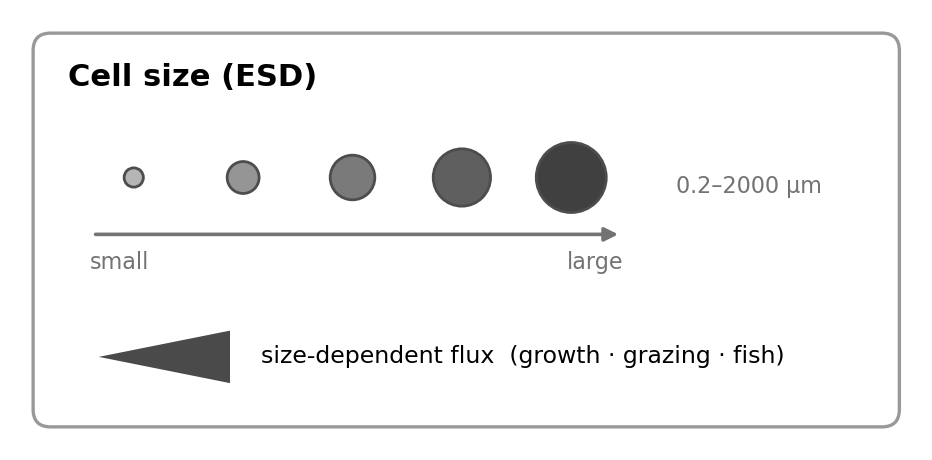

In [9]:
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

fig, ax = plt.subplots(figsize=(5.2, 2.4))
ax.add_patch(FancyBboxPatch((0.15, 0.15), 9.9, 4.5,
             boxstyle='round,pad=0,rounding_size=0.2', fc='white', ec='0.6', lw=1.2))

# title
ax.text(0.55, 4.05, 'Cell size (ESD)', fontsize=11, fontweight='bold')

# row 1 — graduated circles = the size axis (small -> large)
xs = np.linspace(1.3, 6.3, 5); rs = np.linspace(0.11, 0.40, 5)
greys = plt.cm.Greys(np.linspace(0.40, 0.80, 5))
for x, r, c in zip(xs, rs, greys):
    ax.add_patch(plt.Circle((x, 3.0), r, fc=c, ec='0.3', lw=1.0))
ax.annotate('', xy=(6.9, 2.35), xytext=(0.8, 2.35),
            arrowprops=dict(arrowstyle='-|>', color='0.45', lw=1.3))
ax.text(0.8, 1.95, 'small', fontsize=8, color='0.45')
ax.text(6.9, 1.95, 'large', fontsize=8, color='0.45', ha='right')
ax.text(7.5, 2.9, '0.2–2000 µm', fontsize=8, color='0.45', va='center')

# row 2 — the wedge badge and what it means
ax.add_patch(Polygon([(0.9, 0.95), (2.4, 0.65), (2.4, 1.25)], closed=True, fc='#4A4A4A', ec='none'))
ax.text(2.75, 0.95, 'size-dependent flux  (growth · grazing · fish)', fontsize=8.5, va='center')

ax.set_xlim(0, 10.2); ax.set_ylim(0, 4.8)
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
plt.show()

lowest return 0.85 -> drops 0.30 into N.top | fish verticals at 3.4, 3.62, 3.84


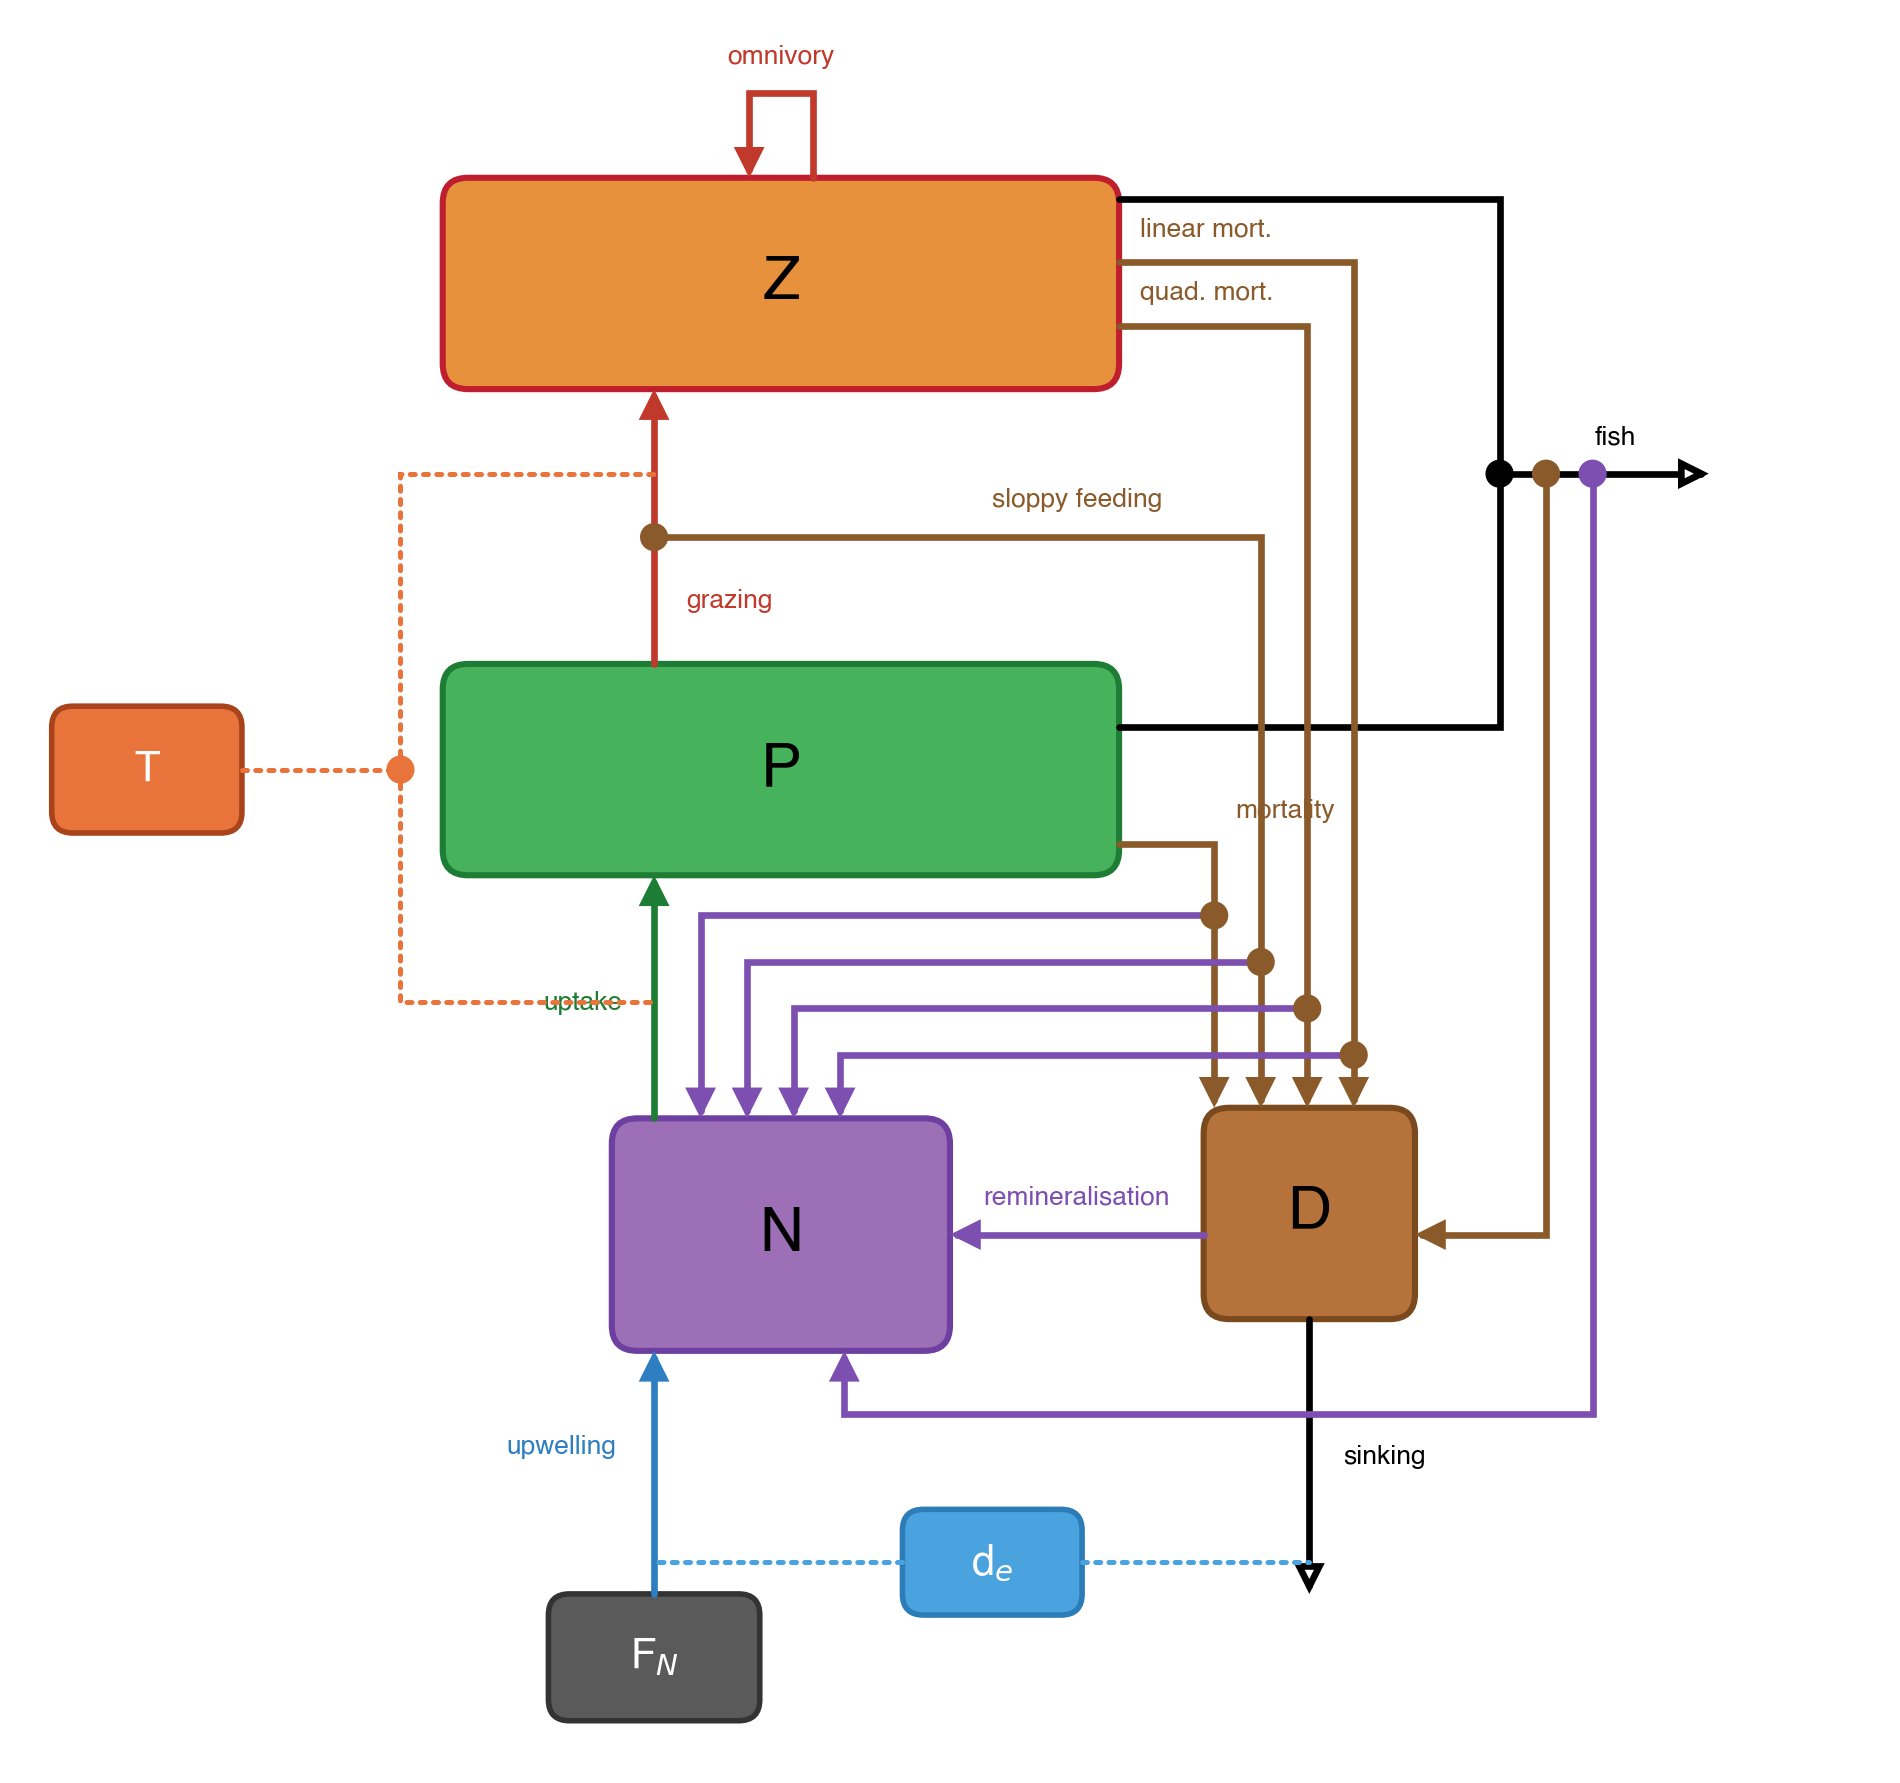

In [16]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family']  = 'Helvetica'

# ===================== GLOBAL RHYTHM =====================
PITCH = 0.22     # one adjacent-line distance for every comb in the figure
CLEAR = 0.25     # guaranteed gap between the lowest return and D's arrowhead

# ===================== PALETTE =====================
PUR, GRN, BRN, ORG = '#7D4FB0', '#1E7D34', '#8A5A2B', '#C0392B'
BLUE, BLACK = '#2E7FC1', 'black'
TCOL, FNCOL, DECOL = '#E8743B', '#5A5A5A', '#4AA3DF'
FILL = {'N':'#9C6FB6','P':'#46B25B','Z':'#E8913C','D':'#B5723A'}
EDGE = {'N':'#6C3FA0','P':'#1E7D34','Z':'#BE1E2D','D':'#7A4A1E'}
SX = -0.6   # production-spine x

# ===================== NODES (D raised back to just above N) =====================
nodes = {
    'N': dict(x=0.0, y=0.0,  w=1.6, h=1.1),   # top .55  bot -.55
    'P': dict(x=0.0, y=2.2,  w=3.2, h=1.0),   # bot 1.7
    'Z': dict(x=0.0, y=4.5,  w=3.2, h=1.0),   # bot 4.0  top 5.0
    'D': dict(x=2.5, y=0.1,  w=1.0, h=1.0),   # top 0.6  (a bit higher than N)
}
forcing = {
    'T':  dict(x=-3.0, y=2.20, w=0.9,  h=0.60, fc=TCOL,  ec='#A8431B', tc='white', lab='T'),
    'FN': dict(x=SX,   y=-2.00,w=1.0,  h=0.60, fc=FNCOL, ec='#333333', tc='white', lab=r'F$_N$'),
    'de': dict(x=1.0,  y=-1.55,w=0.85, h=0.50, fc=DECOL, ec='#2C7CB8', tc='white', lab=r'd$_e$'),
}
Dtop  = nodes['D']['y'] + nodes['D']['h']/2   # 0.6
NtopY = nodes['N']['y'] + nodes['N']['h']/2   # 0.55
X0    = 3.4                                    # fish merge / feed column

# ===================== FLUX EDGES =====================
edges = [
    dict(pts=[(SX,-1.7),(SX,-0.55)],               col=BLUE, head='closed', label='upwelling', lab=(SX-0.18,-1.0,'right','center')),
    dict(pts=[(SX,0.55),(SX,1.7)],                 col=GRN,  head='closed', label='uptake',    lab=(SX-0.15,1.1,'right','center')),
    dict(pts=[(SX,2.7),(SX,4.0)],                  col=ORG,  head='closed', label='grazing',   lab=(SX+0.15,3.0,'left','center')),
    dict(pts=[(0.15,5.0),(0.15,5.4),(-0.15,5.4),(-0.15,5.0)], col=ORG, head='closed', label='omnivory', lab=(0,5.52,'center','bottom')),
    dict(pts=[(2.0,0.0),(0.8,0.0)],                col=PUR,  head='closed', label='remineralisation', lab=(1.4,0.12,'center','bottom')),
    dict(pts=[(2.5,-0.4),(2.5,-1.7)],              col=BLACK,head='open',   label='sinking',   lab=(2.66,-1.05,'left','center')),
    # fish: Z+P feed -> export spine -> three evenly-spaced verticals (feed / D / N)
    dict(pts=[(1.6,4.9),(X0,4.9),(X0,3.6)],                col=BLACK, head='none'),                       # Z feed
    dict(pts=[(1.6,2.4),(X0,2.4),(X0,3.6)],                col=BLACK, head='none'),                       # P feed (col 0)
    dict(pts=[(X0,3.6),(X0+2*PITCH+0.55,3.6)],             col=BLACK, head='open', label='fish', lab=(X0+0.55,3.72,'center','bottom')),
    dict(pts=[(X0+PITCH,3.6),(X0+PITCH,0.0),(3.0,0.0)],    col=BRN,   head='closed'),                     # -> D  (col 1)
    dict(pts=[(X0+2*PITCH,3.6),(X0+2*PITCH,-0.85),(0.3,-0.85),(0.3,-0.55)], col=PUR, head='closed'),      # -> N  (col 2)
    # forcing (dotted)
    dict(pts=[(-2.55,2.2),(-1.8,2.2),(-1.8,3.6),(SX,3.6)], col=TCOL, head='none', ls=':', lw=1.8),
    dict(pts=[(-1.8,2.2),(-1.8,1.1),(SX,1.1)],            col=TCOL, head='none', ls=':', lw=1.8),
    dict(pts=[(0.575,-1.55),(SX,-1.55)],                  col=DECOL,head='none', ls=':', lw=1.8),
    dict(pts=[(1.425,-1.55),(2.5,-1.55)],                 col=DECOL,head='none', ls=':', lw=1.8),
]

# ===================== RIGHT CHANNEL — everything keyed to PITCH/CLEAR =====================
LX0 = 2.05
ret_lo = Dtop + CLEAR                          # lowest return height (now 0.85)
ch_defs = [((1.6,1.85),'mortality',(2.15,1.95)), ((SX,3.3),'sloppy feeding',(1.0,3.42)),
           ((1.6,4.3),'quad. mort.',(1.7,4.4)), ((1.6,4.6),'linear mort.',(1.7,4.7))]
DOTS = []
for i,(src,label,lab) in enumerate(ch_defs):
    lx = LX0 + i*PITCH
    ry = ret_lo + (3-i)*PITCH
    nx = (SX + PITCH) + i*PITCH
    edges.append(dict(pts=[src,(lx,src[1]),(lx,Dtop)], col=BRN, head='closed', label=label, lab=(lab[0],lab[1],'left','bottom')))
    edges.append(dict(pts=[(lx,ry),(nx,ry),(nx,NtopY)], col=PUR, head='closed'))
    DOTS.append((lx,ry,BRN))
DOTS += [(SX,3.3,BRN), (X0,3.6,BLACK),(X0+PITCH,3.6,BRN),(X0+2*PITCH,3.6,PUR), (-1.8,2.2,TCOL)]

# ===================== RENDERER =====================
def draw_arrow(ax, pts, col, head, ls='-', lw=2.4):
    style = {'closed':'-|>','open':'-|>','none':'-'}[head]
    ax.add_patch(FancyArrowPatch(path=Path(pts, [Path.MOVETO]+[Path.LINETO]*(len(pts)-1)),
        arrowstyle=style, mutation_scale=18, lw=lw, edgecolor=col,
        facecolor=(col if head=='closed' else 'white'), shrinkA=0, shrinkB=0,
        joinstyle='miter', linestyle=ls, zorder=3))

fig, ax = plt.subplots(figsize=(9.6, 9.2))
for k, n in nodes.items():
    ax.add_patch(FancyBboxPatch((n['x']-n['w']/2, n['y']-n['h']/2), n['w'], n['h'],
                 boxstyle='round,pad=0,rounding_size=0.12', fc=FILL[k], ec=EDGE[k], lw=2.2, zorder=2))
    ax.text(n['x'], n['y'], k, ha='center', va='center', fontsize=22, fontweight='bold', zorder=4)
for k, f in forcing.items():
    ax.add_patch(FancyBboxPatch((f['x']-f['w']/2, f['y']-f['h']/2), f['w'], f['h'],
                 boxstyle='round,pad=0,rounding_size=0.10', fc=f['fc'], ec=f['ec'], lw=2.0, zorder=2))
    ax.text(f['x'], f['y'], f['lab'], ha='center', va='center', fontsize=15, fontweight='bold', color=f['tc'], zorder=4)
for e in edges:
    draw_arrow(ax, e['pts'], e['col'], e['head'], e.get('ls','-'), e.get('lw',2.4))
    if e.get('label'):
        lx, ly, ha, va = e['lab']
        ax.text(lx, ly, e['label'], ha=ha, va=va, fontsize=9.5, fontweight='bold', color=e['col'])
for x, y, c in DOTS:
    ax.add_patch(plt.Circle((x, y), 0.06, color=c, zorder=5))

for art in ax.findobj():
    art.set_clip_on(False)

ax.set_xlim(-3.6, 5.2); ax.set_ylim(-2.5, 5.75)
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
fig.savefig('npzd_schematic.svg', bbox_inches='tight', pad_inches=0.05, transparent=True)
print(f'lowest return {ret_lo:.2f} -> drops {ret_lo-NtopY:.2f} into N.top | fish verticals at {X0}, {X0+PITCH:.2f}, {X0+2*PITCH:.2f}')
plt.show()

P 156.6x32.3pt | Z 156.6x35.0pt  (Artboard 156.6x32.3 / 156.6x35.0)


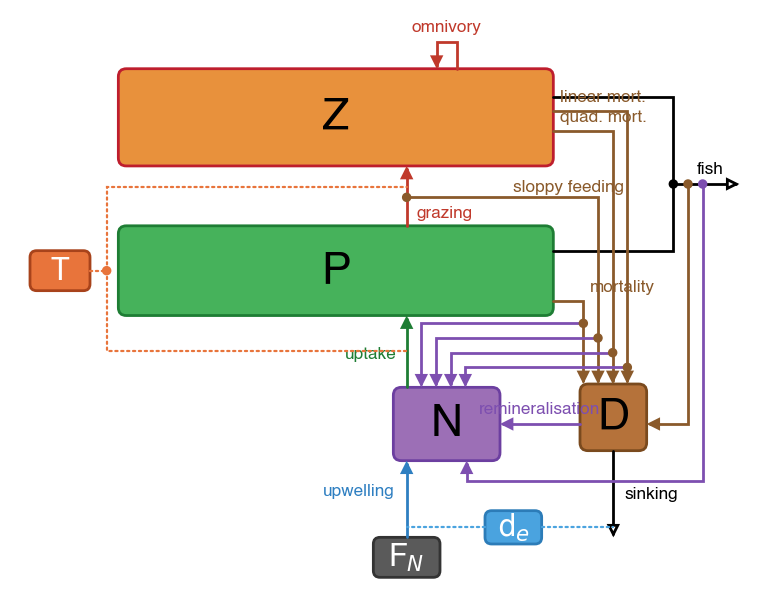

In [17]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family']  = 'Helvetica'

# ---- scale & style (matched to Artboard 1.pdf) ----
PPU  = 24.0
HEAD = 8
LW_MAIN, LW_DOT = 1.0, 0.8
F_BOX, F_FORCE, F_LAB = 16, 11, 6.2
PITCH, CLEAR = 0.22, 0.25

# ---- palette ----
PUR, GRN, BRN, ORG = '#7D4FB0', '#1E7D34', '#8A5A2B', '#C0392B'
BLUE, BLACK = '#2E7FC1', 'black'
TCOL, FNCOL, DECOL = '#E8743B', '#5A5A5A', '#4AA3DF'
FILL = {'N':'#9C6FB6','P':'#46B25B','Z':'#E8913C','D':'#B5723A'}
EDGE = {'N':'#6C3FA0','P':'#1E7D34','Z':'#BE1E2D','D':'#7A4A1E'}
SX = -0.6

# ---- nodes: P & Z at exact Artboard size; bands grow leftward (right edge fixed at 1.6) ----
PZ_W  = 156.6/PPU                 # 6.525
PZ_CX = 1.6 - PZ_W/2              # keeps right edge at 1.6
nodes = {
    'N': dict(x=0.0,   y=0.0,  w=1.6,   h=1.1),
    'P': dict(x=PZ_CX, y=2.30, w=PZ_W,  h=32.3/PPU),
    'Z': dict(x=PZ_CX, y=4.60, w=PZ_W,  h=35.0/PPU),
    'D': dict(x=2.5,   y=0.1,  w=1.0,   h=1.0),
}
forcing = {
    'T':  dict(x=-5.8, y=2.30, w=0.9,  h=0.60, fc=TCOL,  ec='#A8431B', tc='white', lab='T'),
    'FN': dict(x=SX,   y=-2.00,w=1.0,  h=0.60, fc=FNCOL, ec='#333333', tc='white', lab=r'F$_N$'),
    'de': dict(x=1.0,  y=-1.55,w=0.85, h=0.50, fc=DECOL, ec='#2C7CB8', tc='white', lab=r'd$_e$'),
}
Pb,Pt = nodes['P']['y']-nodes['P']['h']/2, nodes['P']['y']+nodes['P']['h']/2
Zb,Zt = nodes['Z']['y']-nodes['Z']['h']/2, nodes['Z']['y']+nodes['Z']['h']/2
Dtop, NtopY = nodes['D']['y']+nodes['D']['h']/2, nodes['N']['y']+nodes['N']['h']/2
X0 = 3.4

edges = [
    dict(pts=[(SX,-1.7),(SX,-0.55)],               col=BLUE, head='closed', label='upwelling', lab=(SX-0.18,-1.0,'right','center')),
    dict(pts=[(SX,0.55),(SX,Pb)],                  col=GRN,  head='closed', label='uptake',    lab=(SX-0.15,1.05,'right','center')),
    dict(pts=[(SX,Pt),(SX,Zb)],                    col=ORG,  head='closed', label='grazing',   lab=(SX+0.15,Pt+0.2,'left','center')),
    dict(pts=[(0.15,Zt),(0.15,Zt+0.4),(-0.15,Zt+0.4),(-0.15,Zt)], col=ORG, head='closed', label='omnivory', lab=(0,Zt+0.52,'center','bottom')),
    dict(pts=[(2.0,0.0),(0.8,0.0)],                col=PUR,  head='closed', label='remineralisation', lab=(1.4,0.12,'center','bottom')),
    dict(pts=[(2.5,-0.4),(2.5,-1.7)],              col=BLACK,head='open',   label='sinking',   lab=(2.66,-1.05,'left','center')),
    dict(pts=[(1.6,4.9),(X0,4.9),(X0,3.6)],                col=BLACK, head='none'),
    dict(pts=[(1.6,2.6),(X0,2.6),(X0,3.6)],                col=BLACK, head='none'),
    dict(pts=[(X0,3.6),(X0+2*PITCH+0.55,3.6)],             col=BLACK, head='open', label='fish', lab=(X0+0.55,3.72,'center','bottom')),
    dict(pts=[(X0+PITCH,3.6),(X0+PITCH,0.0),(3.0,0.0)],    col=BRN,   head='closed'),
    dict(pts=[(X0+2*PITCH,3.6),(X0+2*PITCH,-0.85),(0.3,-0.85),(0.3,-0.55)], col=PUR, head='closed'),
    dict(pts=[(-5.35,2.3),(-5.1,2.3),(-5.1,3.55),(SX,3.55)], col=TCOL, head='none', ls=':', lw=LW_DOT),
    dict(pts=[(-5.1,2.3),(-5.1,1.1),(SX,1.1)],              col=TCOL, head='none', ls=':', lw=LW_DOT),
    dict(pts=[(0.575,-1.55),(SX,-1.55)],                    col=DECOL,head='none', ls=':', lw=LW_DOT),
    dict(pts=[(1.425,-1.55),(2.5,-1.55)],                   col=DECOL,head='none', ls=':', lw=LW_DOT),
]

# right channel (unchanged)
LX0 = 2.05
ret_lo = Dtop + CLEAR
ch_defs = [((1.6,1.85),'mortality',(2.15,1.95)), ((SX,3.4),'sloppy feeding',(1.0,3.45)),
           ((1.6,4.4),'quad. mort.',(1.7,4.5)), ((1.6,4.7),'linear mort.',(1.7,4.8))]
DOTS = []
for i,(src,label,lab) in enumerate(ch_defs):
    lx, ry, nx = LX0+i*PITCH, ret_lo+(3-i)*PITCH, (SX+PITCH)+i*PITCH
    edges.append(dict(pts=[src,(lx,src[1]),(lx,Dtop)], col=BRN, head='closed', label=label, lab=(lab[0],lab[1],'left','bottom')))
    edges.append(dict(pts=[(lx,ry),(nx,ry),(nx,NtopY)], col=PUR, head='closed'))
    DOTS.append((lx,ry,BRN))
DOTS += [(SX,3.4,BRN), (X0,3.6,BLACK),(X0+PITCH,3.6,BRN),(X0+2*PITCH,3.6,PUR), (-5.1,2.3,TCOL)]

def draw_arrow(ax, pts, col, head, ls='-', lw=LW_MAIN):
    style = {'closed':'-|>','open':'-|>','none':'-'}[head]
    ax.add_patch(FancyArrowPatch(path=Path(pts, [Path.MOVETO]+[Path.LINETO]*(len(pts)-1)),
        arrowstyle=style, mutation_scale=HEAD, lw=lw, edgecolor=col,
        facecolor=(col if head=='closed' else 'white'), shrinkA=0, shrinkB=0,
        joinstyle='miter', linestyle=ls, zorder=3))

xlo, xhi, ylo, yhi = -6.4, 4.6, -2.4, 6.0
fig = plt.figure(figsize=((xhi-xlo)*PPU/72, (yhi-ylo)*PPU/72))
ax  = fig.add_axes([0,0,1,1])
for k, n in nodes.items():
    ax.add_patch(FancyBboxPatch((n['x']-n['w']/2, n['y']-n['h']/2), n['w'], n['h'],
                 boxstyle='round,pad=0,rounding_size=0.12', fc=FILL[k], ec=EDGE[k], lw=LW_MAIN, zorder=2))
    ax.text(n['x'], n['y'], k, ha='center', va='center', fontsize=F_BOX, fontweight='bold', zorder=4)
for k, f in forcing.items():
    ax.add_patch(FancyBboxPatch((f['x']-f['w']/2, f['y']-f['h']/2), f['w'], f['h'],
                 boxstyle='round,pad=0,rounding_size=0.10', fc=f['fc'], ec=f['ec'], lw=LW_MAIN, zorder=2))
    ax.text(f['x'], f['y'], f['lab'], ha='center', va='center', fontsize=F_FORCE, fontweight='bold', color=f['tc'], zorder=4)
for e in edges:
    draw_arrow(ax, e['pts'], e['col'], e['head'], e.get('ls','-'), e.get('lw', LW_MAIN))
    if e.get('label'):
        lx, ly, ha, va = e['lab']
        ax.text(lx, ly, e['label'], ha=ha, va=va, fontsize=F_LAB, fontweight='bold', color=e['col'])
for x, y, c in DOTS:
    ax.add_patch(plt.Circle((x, y), 0.05, color=c, zorder=5))
for art in ax.findobj():
    art.set_clip_on(False)
ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
ax.set_aspect('equal'); ax.axis('off')
fig.savefig('npzd_schematic.svg', bbox_inches='tight', pad_inches=0.03, transparent=True)
print(f'P {PZ_W*PPU:.1f}x{nodes["P"]["h"]*PPU:.1f}pt | Z {PZ_W*PPU:.1f}x{nodes["Z"]["h"]*PPU:.1f}pt  (Artboard 156.6x32.3 / 156.6x35.0)')
plt.show()

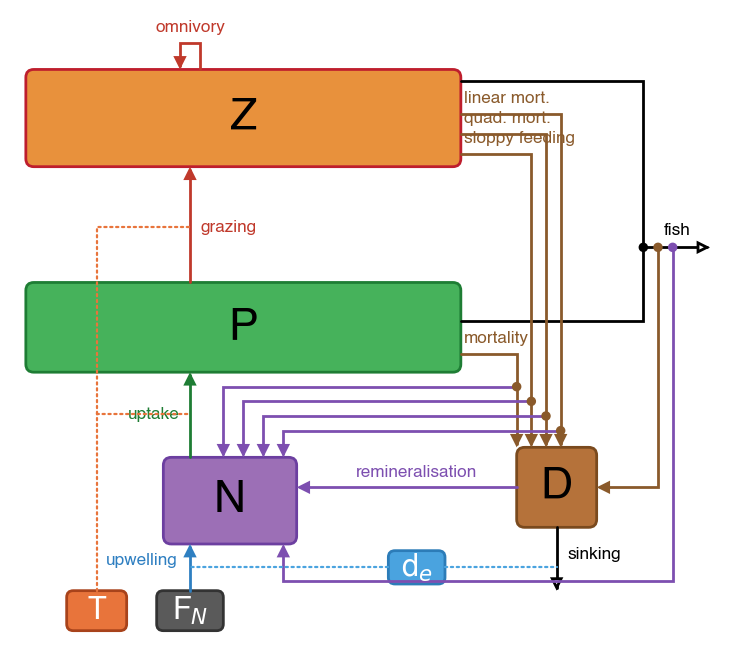

In [20]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.path import Path
plt.rcParams['svg.fonttype']='none'; plt.rcParams['font.family']='Helvetica'
PPU,PITCH,CLEAR = 24.0,0.22,0.25
HEAD,GAP_HEAD = 8,7.0
LW_MAIN,LW_DOT = 1.0,0.8
F_BOX,F_FORCE,F_LAB = 16,11,6.2
PUR,GRN,BRN,ORG='#7D4FB0','#1E7D34','#8A5A2B','#C0392B'; BLUE,BLACK='#2E7FC1','black'
TCOL,FNCOL,DECOL='#E8743B','#5A5A5A','#4AA3DF'
FILL={'N':'#9C6FB6','P':'#46B25B','Z':'#E8913C','D':'#B5723A'}
EDGE={'N':'#6C3FA0','P':'#1E7D34','Z':'#BE1E2D','D':'#7A4A1E'}

SX,PZ_W = -2.4, 156.6/PPU            # production spine, left of band centre
nodes={'N':dict(x=-1.8,y=-0.3,w=2.0,h=1.3),    # left, down, larger
       'P':dict(x=-1.6,y=2.3,  w=PZ_W,h=32.3/PPU),
       'Z':dict(x=-1.6,y=5.439,w=PZ_W,h=35.0/PPU),
       'D':dict(x=3.1,y=-0.1,w=1.2,h=1.2)}      # right, down, larger
forcing={'T': dict(x=-3.8,y=-1.95,w=0.9, h=0.6, fc=TCOL, ec='#A8431B',tc='white',lab='T'),   # under P
         'FN':dict(x=SX,  y=-1.95,w=1.0, h=0.6, fc=FNCOL,ec='#333333',tc='white',lab=r'F$_N$'),
         'de':dict(x=1.0, y=-1.30,w=0.85,h=0.5, fc=DECOL,ec='#2C7CB8',tc='white',lab=r'd$_e$')}
Pb,Pt = 1.627, nodes['P']['y']+nodes['P']['h']/2
Zb,Zt = 4.71,  nodes['Z']['y']+nodes['Z']['h']/2
RE   = nodes['P']['x']+nodes['P']['w']/2
Dtop,NtopY = nodes['D']['y']+nodes['D']['h']/2, nodes['N']['y']+nodes['N']['h']/2
DR,NR = nodes['D']['x']+nodes['D']['w']/2, nodes['N']['x']+nodes['N']['w']/2
Nb = nodes['N']['y']-nodes['N']['h']/2

edges=[
 dict(pts=[(SX,-1.65),(SX,Nb)],col=BLUE,head='closed',label='upwelling',lab=(SX-0.18,-1.2,'right','center')),
 dict(pts=[(SX,NtopY),(SX,Pb)],col=GRN, head='closed',label='uptake',   lab=(SX-0.15,1.0,'right','center')),
 dict(pts=[(SX,Pt),(SX,Zb)],   col=ORG, head='closed',label='grazing',  lab=(SX+0.15,3.8,'left','center')),
 dict(pts=[(SX+0.15,Zt),(SX+0.15,Zt+0.4),(SX-0.15,Zt+0.4),(SX-0.15,Zt)],col=ORG,head='closed',label='omnivory',lab=(SX,Zt+0.52,'center','bottom')),
 dict(pts=[(nodes['D']['x']-nodes['D']['w']/2,-0.1),(NR,-0.1)],col=PUR,head='closed',label='remineralisation',lab=(1.0,0.02,'center','bottom')),
 dict(pts=[(3.1,nodes['D']['y']-nodes['D']['h']/2),(3.1,-1.65)],col=BLACK,head='open',label='sinking',lab=(3.26,-1.1,'left','center')),
 # fish (right)
 dict(pts=[(RE,6.0),(4.4,6.0),(4.4,3.5)],col=BLACK,head='none'),
 dict(pts=[(RE,2.4),(4.4,2.4),(4.4,3.5)],col=BLACK,head='none'),
 dict(pts=[(4.4,3.5),(5.4,3.5)],col=BLACK,head='open',label='fish',lab=(4.9,3.65,'center','bottom')),
 dict(pts=[(4.62,3.5),(4.62,-0.1),(DR,-0.1)],col=BRN,head='closed'),
 dict(pts=[(4.84,3.5),(4.84,-1.5),(-1.0,-1.5),(-1.0,Nb)],col=PUR,head='closed'),
 # forcing (T under P -> growth clean, grazing crosses P; d_e horizontal)
 dict(pts=[(-3.8,-1.65),(-3.8,1.0),(SX,1.0)],col=TCOL,head='none',ls=':',lw=LW_DOT),
 dict(pts=[(-3.8,1.0),(-3.8,3.8),(SX,3.8)],  col=TCOL,head='none',ls=':',lw=LW_DOT),
 dict(pts=[(0.575,-1.30),(SX,-1.30)],        col=DECOL,head='none',ls=':',lw=LW_DOT),
 dict(pts=[(1.425,-1.30),(3.1,-1.30)],       col=DECOL,head='none',ls=':',lw=LW_DOT),
]

# ---- single right channel: brown -> D.top, purple peels back to N.top (gap from uptake) ----
LX0, ret_lo, NX0 = 2.5, Dtop+CLEAR, -1.9
losses=[('mortality',(RE,1.9)),('sloppy feeding',(RE,4.9)),('quad. mort.',(RE,5.2)),('linear mort.',(RE,5.5))]
DOTS=[]
for i,(label,src) in enumerate(losses):
    lane=LX0+i*PITCH; ry=ret_lo+(3-i)*PITCH; nx=NX0+i*0.30
    edges.append(dict(pts=[src,(lane,src[1]),(lane,Dtop)],col=BRN,head='closed',label=label,lab=(src[0]+0.05,src[1]+0.12,'left','bottom')))
    edges.append(dict(pts=[(lane,ry),(nx,ry),(nx,NtopY)],col=PUR,head='closed'))
    DOTS.append((lane,ry,BRN))
DOTS+=[(4.4,3.5,BLACK),(4.62,3.5,BRN),(4.84,3.5,PUR)]

def draw_arrow(ax,pts,col,head,ls='-',lw=LW_MAIN):
    style={'closed':'-|>','open':'-|>','none':'-'}[head]; sb=GAP_HEAD if head in('closed','open') else 0
    ax.add_patch(FancyArrowPatch(path=Path(pts,[Path.MOVETO]+[Path.LINETO]*(len(pts)-1)),
        arrowstyle=style,mutation_scale=HEAD,lw=lw,edgecolor=col,
        facecolor=(col if head=='closed' else 'white'),shrinkA=0,shrinkB=sb,joinstyle='miter',linestyle=ls,zorder=3))

xlo,xhi,ylo,yhi=-4.95,5.5,-2.3,6.85
fig=plt.figure(figsize=((xhi-xlo)*PPU/72,(yhi-ylo)*PPU/72)); ax=fig.add_axes([0,0,1,1])
for k,n in nodes.items():
    ax.add_patch(FancyBboxPatch((n['x']-n['w']/2,n['y']-n['h']/2),n['w'],n['h'],boxstyle='round,pad=0,rounding_size=0.12',fc=FILL[k],ec=EDGE[k],lw=LW_MAIN,zorder=2))
    ax.text(n['x'],n['y'],k,ha='center',va='center',fontsize=F_BOX,fontweight='bold',zorder=4)
for k,f in forcing.items():
    ax.add_patch(FancyBboxPatch((f['x']-f['w']/2,f['y']-f['h']/2),f['w'],f['h'],boxstyle='round,pad=0,rounding_size=0.10',fc=f['fc'],ec=f['ec'],lw=LW_MAIN,zorder=2))
    ax.text(f['x'],f['y'],f['lab'],ha='center',va='center',fontsize=F_FORCE,fontweight='bold',color=f['tc'],zorder=4)
for e in edges:
    draw_arrow(ax,e['pts'],e['col'],e['head'],e.get('ls','-'),e.get('lw',LW_MAIN))
    if e.get('label'):
        lx,ly,ha,va=e['lab']; ax.text(lx,ly,e['label'],ha=ha,va=va,fontsize=F_LAB,fontweight='bold',color=e['col'])
for x,y,c in DOTS: ax.add_patch(plt.Circle((x,y),0.05,color=c,zorder=5))
for art in ax.findobj(): art.set_clip_on(False)
ax.set_xlim(xlo,xhi); ax.set_ylim(ylo,yhi); ax.set_aspect('equal'); ax.axis('off')
fig.savefig('npzd_schematic.svg',bbox_inches='tight',pad_inches=0.03,transparent=True)
plt.show()